## Dataset Column Descriptions (Numbered)

1. **`x`** – Longitude coordinate of the observation station.
2. **`y`** – Latitude coordinate of the observation station.
3. **`identifier`** – Unique record identifier combining instrument and metadata.
4. **`file_path`** – File path to the WOUDC archive where the record is stored.
5. **`dataset_id`** – Dataset type, e.g., "TotalOzone_1.0".
6. **`station_id`** – Numeric ID representing the station.
7. **`station_name`** – Name of the observation station.
8. **`station_gaw_id`** – Global Atmosphere Watch (GAW) ID for the station.
9. **`station_gaw_url`** – URL to the station’s GAWSIS information page.
10. **`contributor_name`** – Name of the organization that submitted the data.
11. **`contributor_id`** – ID of the contributing organization.
12. **`contributor_url`** – URL for the contributor's organization or data page.
13. **`country_id`** – Country code (e.g., "BRA" for Brazil).
14. **`country_name_en`** – Country name in English.
15. **`country_name_fr`** – Country name in French.
16. **`gaw_id`** – Unique GAWSIS identifier for the observation site.
17. **`instrument_name`** – Type or name of the ozone measuring instrument.
18. **`instrument_model`** – Specific model of the instrument.
19. **`instrument_serial`** – Serial number of the instrument.
20. **`observation_date`** – Timestamp of the measurement.
21. **`daily_date`** – Date of the daily ozone observation.
22. **`daily_wlcode`** – Wavelength code used in observation.
23. **`daily_obscode`** – Code indicating observation method or quality.
24. **`daily_columno3`** – Daily total column ozone in Dobson Units (DU).
25. **`daily_stdevo3`** – Standard deviation of the ozone measurements.
26. **`daily_utc_begin`** – UTC time when the first observation began.
27. **`daily_utc_end`** – UTC time when the last observation ended.
28. **`daily_utc_mean`** – Mean UTC time of the day’s observations.
29. **`daily_nobs`** – Number of ozone observations taken in the day.
30. **`daily_mmu`** – Measurement uncertainty of daily ozone data.
31. **`daily_columnso2`** – Measured sulfur dioxide (SO₂) column (if available).
32. **`monthly_date`** – Date representing the month of the aggregated record.
33. **`monthly_columno3`** – Monthly average ozone column value.
34. **`monthly_stdevo3`** – Standard deviation of the monthly ozone.
35. **`monthly_npts`** – Number of measurements used to calculate the monthly average.
36. **`url`** – Direct link to the source data file on the WOUDC server.


**Combining  8 Countries Datasets**
<br>
<ol>
<li>Argentina</li>
<li>Brazil</li>
<li>Canada</li>
<li>Chile</li>
<li>Greenland</li>
<li>Mexico</li>
<li>Peru</li>
<li>USA</li>
</ol>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.api import ExponentialSmoothing, SimpleExpSmoothing, Holt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler,StandardScaler
import optuna
from optuna.samplers import TPESampler
import plotly.express as px
import plotly.graph_objects as go


c:\Users\Abir Hossain\AppData\Local\Programs\Python\Python37\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df1=pd.read_csv('combined_dataset/totalozone_ATA.csv')
df2=pd.read_csv('combined_dataset/totalozone_GRL.csv')
df3=pd.read_csv('combined_dataset/totalozone_CAN.csv')
df4=pd.read_csv('combined_dataset/totalozone_USA.csv')
df5=pd.read_csv('combined_dataset/totalozone_ARG.csv')
df6=pd.read_csv('combined_dataset/totalozone_BRA.csv')
df7=pd.read_csv('combined_dataset/totalozone_AUS.csv')
df8=pd.read_csv('combined_dataset/totalozone_NZL.csv')
df9=pd.read_csv('combined_dataset/totalozone_IND.csv')
df10=pd.read_csv('combined_dataset/totalozone_CHN.csv')
df11=pd.read_csv('combined_dataset/totalozone_MEX.csv')
df12=pd.read_csv('combined_dataset/totalozone_ASM.csv')

df=pd.concat([df1, df2, df3, df4, df5, df6, df7, df8,df9,df10,df11,df12], ignore_index=True)
df['daily_date'] = pd.to_datetime(df['daily_date'], format='%Y-%m-%d')
df.head()






c:\Users\Abir Hossain\AppData\Local\Programs\Python\Python37\lib\site-packages\IPython\core\interactiveshell.py:3258: DtypeWarning: Columns (22,25) have mixed types.Specify dtype option on import or set low_memory=False.
  interactivity=interactivity, compiler=compiler, result=result)
c:\Users\Abir Hossain\AppData\Local\Programs\Python\Python37\lib\site-packages\IPython\core\interactiveshell.py:3258: DtypeWarning: Columns (22) have mixed types.Specify dtype option on import or set low_memory=False.
  interactivity=interactivity, compiler=compiler, result=result)
c:\Users\Abir Hossain\AppData\Local\Programs\Python\Python37\lib\site-packages\IPython\core\interactiveshell.py:3258: DtypeWarning: Columns (18,22) have mixed types.Specify dtype option on import or set low_memory=False.
  interactivity=interactivity, compiler=compiler, result=result)
c:\Users\Abir Hossain\AppData\Local\Programs\Python\Python37\lib\site-packages\IPython\core\interactiveshell.py:3258: DtypeWarning: Columns (21,2

,x,y,identifier,file_path,dataset_id,station_id,station_name,station_gaw_id,station_gaw_url,contributor_name,...,daily_utc_end,daily_utc_mean,daily_nobs,daily_mmu,daily_columnso2,monthly_date,monthly_columno3,monthly_stdevo3,monthly_npts,url
0,140.017,-66.666,SAOZ:CP200_NMOS1024:17:TotalOzone_1.0:028:CNRS...,/apps/data/wdr-ingest/Archive-NewFormat/TotalO...,TotalOzone_1.0,28,Dumont d'Urville,DDU,https://gawsis.meteoswiss.ch/GAWSIS/index.html...,National Centre for Scientific Research - France,...,NaN,NaN,2.0,NaN,NaN,2025-02-01T00:00:00Z,315.8,7.45,26.0,https://woudc.org/archive/Archive-NewFormat/To...
1,39.580,-69.010,Brewer:MKIII:252:TotalOzone_1.0:101:JMA:WOUDC:...,/apps/data/wdr-ingest/Archive-NewFormat/TotalO...,TotalOzone_1.0,101,Syowa,SYO,https://gawsis.meteoswiss.ch/GAWSIS/index.html...,Japan Meteorological Agency,...,14.35,9.25,28.0,2.368,NaN,2025-02-01T00:00:00Z,313.4,10.90,22.0,https://woudc.org/archive/Archive-NewFormat/To...
2,123.312,-75.103,SAOZ:CP200_NMOS1024:27:TotalOzone_1.0:492:CNRS...,/apps/data/wdr-ingest/Archive-NewFormat/TotalO...,TotalOzone_1.0,492,"Concordia, Dôme C",DCC,https://gawsis.meteoswiss.ch/GAWSIS/index.html...,National Centre for Scientific Research - France,...,NaN,NaN,2.0,NaN,NaN,2025-02-01T00:00:00Z,314.6,8.68,28.0,https://woudc.org/archive/Archive-NewFormat/To...
3,140.017,-66.666,SAOZ:CP200_NMOS1024:17:TotalOzone_1.0:028:CNRS...,/apps/data/wdr-ingest/Archive-NewFormat/TotalO...,TotalOzone_1.0,28,Dumont d'Urville,DDU,https://gawsis.meteoswiss.ch/GAWSIS/index.html...,National Centre for Scientific Research - France,...,NaN,NaN,2.0,NaN,NaN,2025-02-01T00:00:00Z,315.8,7.45,26.0,https://woudc.org/archive/Archive-NewFormat/To...
4,39.580,-69.010,Brewer:MKIII:252:TotalOzone_1.0:101:JMA:WOUDC:...,/apps/data/wdr-ingest/Archive-NewFormat/TotalO...,TotalOzone_1.0,101,Syowa,SYO,https://gawsis.meteoswiss.ch/GAWSIS/index.html...,Japan Meteorological Agency,...,10.46,8.15,15.0,2.261,NaN,2025-02-01T00:00:00Z,313.4,10.90,22.0,https://woudc.org/archive/Archive-NewFormat/To...


<h2>Visualization</h2>

**Area Chart of Year Vs Ozone**

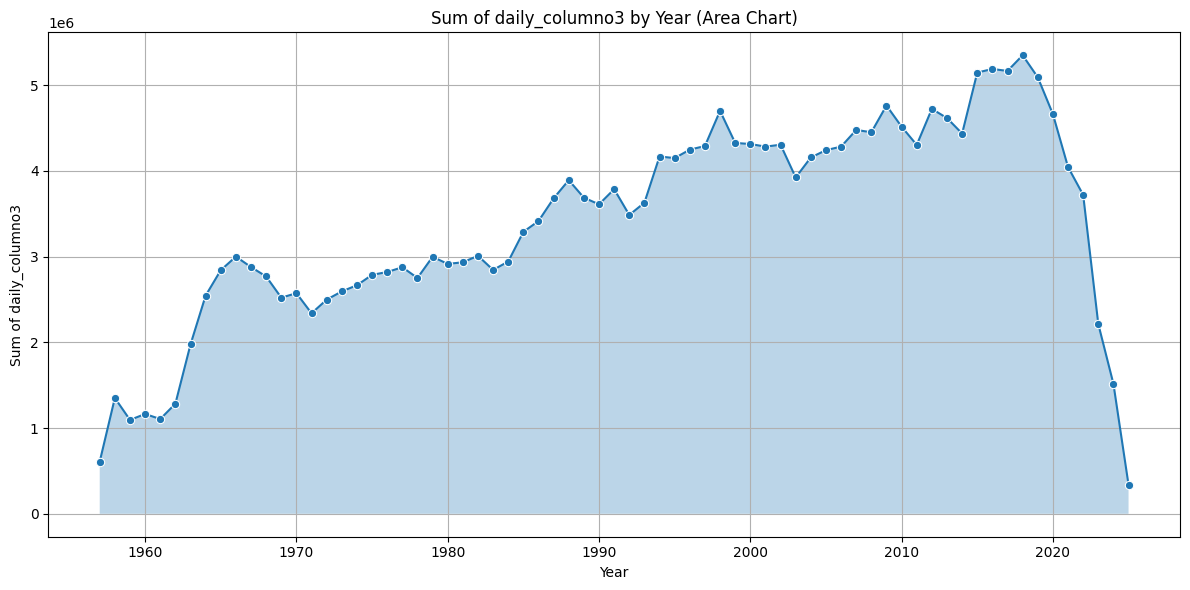

In [3]:
df['year'] = pd.to_numeric(df['daily_date'].dt.year, errors='coerce')

plt.figure(figsize=(12, 6))
df_yearly = df.groupby('year')['daily_columno3'].sum().reset_index()
sns.lineplot(data=df_yearly, x='year', y='daily_columno3', marker='o')
plt.fill_between(df_yearly['year'], df_yearly['daily_columno3'], alpha=0.3)
plt.title('Sum of daily_columno3 by Year (Area Chart)')
plt.ylabel('Sum of daily_columno3')
plt.xlabel('Year')
plt.grid(True)
plt.tight_layout()
plt.show()


**Bar Chart of Year Vs Ozone (After and Before 1989)**

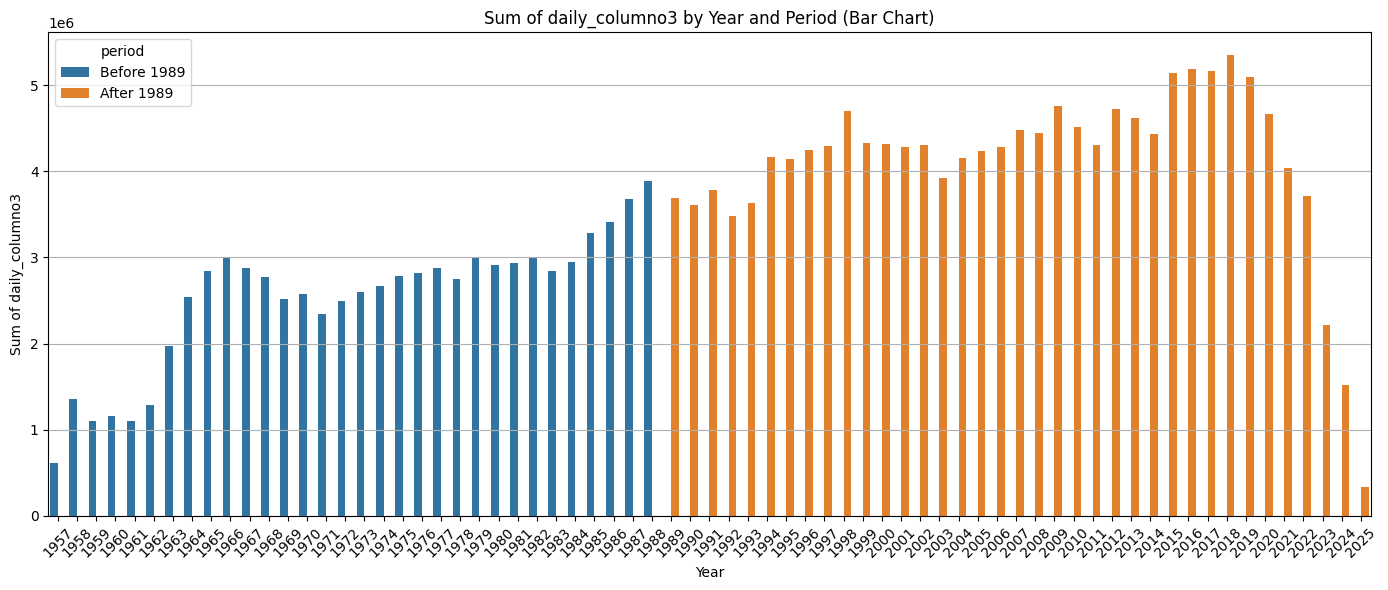

In [4]:
df['period'] = df['year'].apply(lambda x: 'Before 1989' if x < 1989 else 'After 1989')

# Group by year and period
df_period = df.groupby(['year', 'period'])['daily_columno3'].sum().reset_index()

# Plot bar chart
plt.figure(figsize=(14, 6))
sns.barplot(data=df_period, x='year', y='daily_columno3', hue='period', dodge=True)

plt.title('Sum of daily_columno3 by Year and Period (Bar Chart)')
plt.ylabel('Sum of daily_columno3')
plt.xlabel('Year')
plt.xticks(rotation=45)
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

**Bar Chart of Year Vs Ozone**

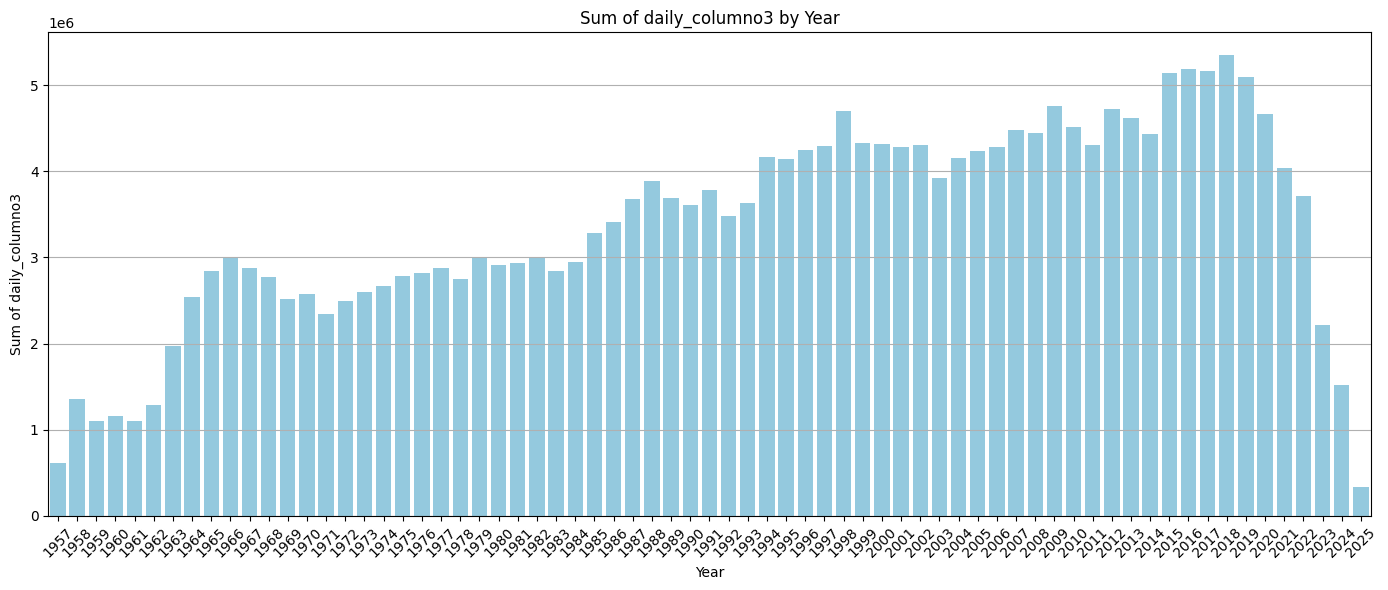

In [5]:
df_yearly = df.groupby('year')['daily_columno3'].sum().reset_index()

# Plot bar chart
plt.figure(figsize=(14, 6))
sns.barplot(data=df_yearly, x='year', y='daily_columno3', color='skyblue')

plt.title('Sum of daily_columno3 by Year')
plt.ylabel('Sum of daily_columno3')
plt.xlabel('Year')
plt.xticks(rotation=45)
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

**Line chart Year vs ozone (before and after 1989)**

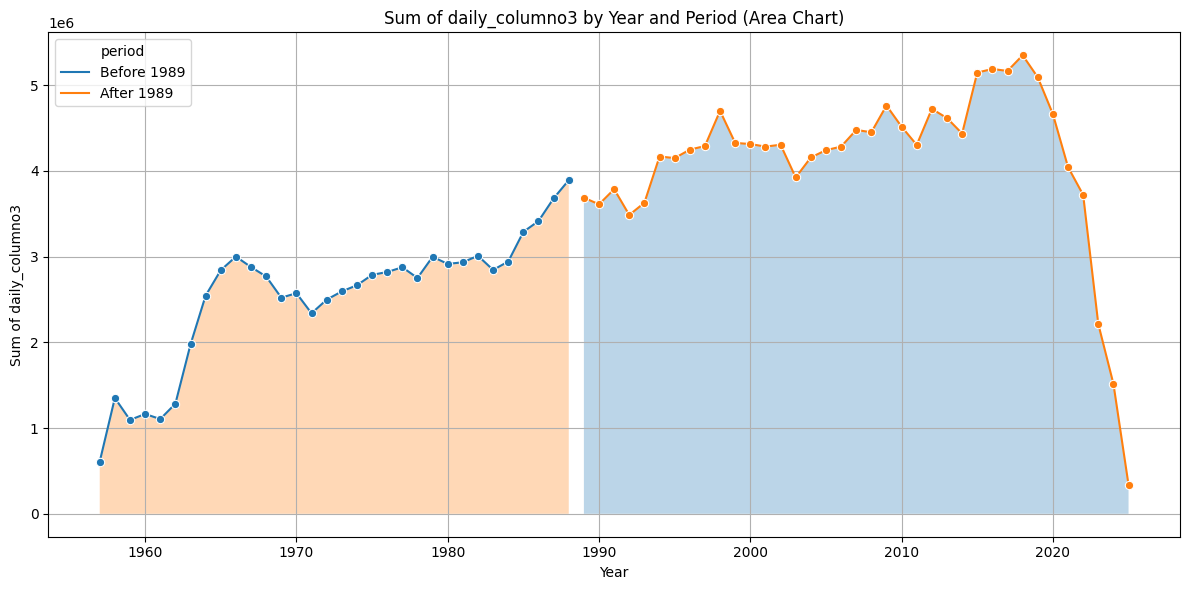

In [6]:
df['period'] = df['year'].apply(lambda x: 'Before 1989' if x < 1989 else 'After 1989')
plt.figure(figsize=(12, 6))
df_period = df.groupby(['year', 'period'])['daily_columno3'].sum().reset_index()
sns.lineplot(data=df_period, x='year', y='daily_columno3', hue='period', marker='o')
for period, group in df_period.groupby('period'):
    plt.fill_between(group['year'], group['daily_columno3'], alpha=0.3, label=f"{period} (area)")
plt.title('Sum of daily_columno3 by Year and Period (Area Chart)')
plt.ylabel('Sum of daily_columno3')
plt.xlabel('Year')
plt.grid(True)
plt.tight_layout()
plt.show()


**Country wise year vs ozone**

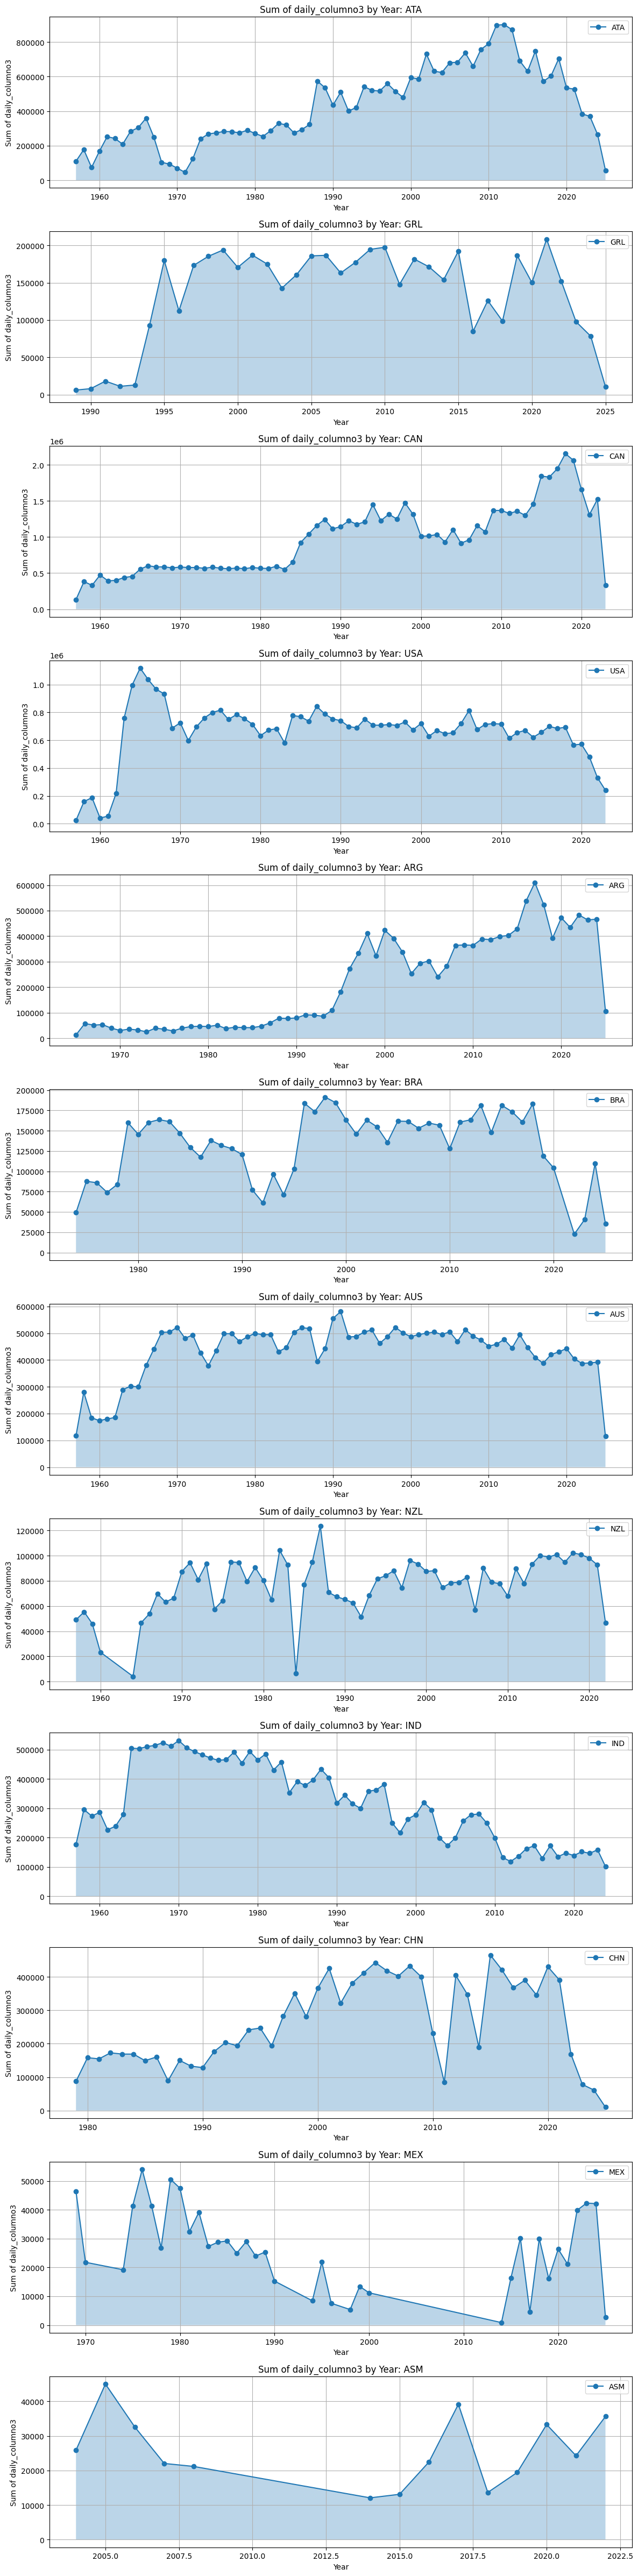

In [7]:
countries = ['ATA', 'GRL', 'CAN', 'USA', 'ARG', 'BRA', 'AUS', 'NZL', 'IND', 'CHN', 'MEX', 'ASM']
6
plt.figure(figsize=(12,4 * len(countries)))
for idx, country in enumerate(countries, 1):
    plt.subplot(len(countries), 1, idx)
    df_country = df[df['country_id'] == country]
    df_yearly = df_country.groupby('year')['daily_columno3'].sum().reset_index()
    plt.plot(df_yearly['year'], df_yearly['daily_columno3'], marker='o', label=country)
    plt.fill_between(df_yearly['year'], df_yearly['daily_columno3'], alpha=0.3)
    plt.title(f'Sum of daily_columno3 by Year: {country}')
    plt.ylabel('Sum of daily_columno3')
    plt.xlabel('Year')
    plt.grid(True)
    plt.legend()
plt.tight_layout()
plt.show()


***<h1>Specific Country wise model check</h1>***

In [8]:
ata_df=df1.copy()
grl_df = df2.copy()
can_df = df3.copy()
usa_df = df4.copy()
arg_df = df5.copy()
bra_df = df6.copy()
aus_df = df7.copy()
nzl_df = df8.copy()
ind_df = df9.copy()
chn_df = df10.copy()
mexo_df = df11.copy()
asm_df = df12.copy()



print("Shape of DataFrames for each country:")
print(f"ATA: {ata_df.shape}")
print(f"GRL: {grl_df.shape}")
print(f"CAN: {can_df.shape}")
print(f"USA: {usa_df.shape}")
print(f"ARG: {arg_df.shape}")
print(f"BRA: {bra_df.shape}")
print(f"AUS: {aus_df.shape}")
print(f"NZL: {nzl_df.shape}")
print(f"IND: {ind_df.shape}")
print(f"CHN: {chn_df.shape}")
print(f"MEX: {mexo_df.shape}")
print(f"ASM: {asm_df.shape}")



Shape of DataFrames for each country:
ATA: (108704, 36)
GRL: (14498, 36)
CAN: (187033, 36)
USA: (140695, 36)
ARG: (45720, 36)
BRA: (24865, 36)
AUS: (102031, 36)
NZL: (15403, 36)
IND: (80658, 36)
CHN: (39220, 36)
MEX: (3615, 36)
ASM: (1451, 36)


In [9]:
# Loop through each dataset
country_dfs = {
    'USA': usa_df,
    'CAN': can_df,
    'BRA': bra_df,
    'ARG': arg_df,
    'AUS': aus_df,
    'GRL': grl_df,
    'IND': ind_df,
    'CHN': chn_df,
    'MEX': mexo_df,
    'ATA': ata_df,
    'NZL': nzl_df,
    'ASM': asm_df
}

for name, df in country_dfs.items():
    print(f"\n📊 Checking dataset: {name}")
    print("=" * 40)

    # Missing Values
    print("🔍 Missing Values:")
    print(df.isnull().sum())
    print("\n📉 Percentage of Missing Values:")
    print((df.isnull().sum() / df.shape[0] * 100).round(2))
    print("*" * 30)

    # Duplicates
    print(f"🧩 Duplicates: {df.duplicated().sum()}")
    print("*" * 30)

    # Garbage Values in object columns
    object_cols = df.select_dtypes(include='object').columns
    if len(object_cols) > 0:
        print("🗑️ Garbage (Unexpected) Values in Object Columns:")
        for col in object_cols:
            print(f"\n🔸 Column: {col}")
            print(df[col].value_counts(dropna=False))
    else:
        print("✅ No object (text) columns to check for garbage.")
    
    print("=" * 40)



📊 Checking dataset: USA
🔍 Missing Values:
x                         0
y                         0
identifier                0
file_path                 0
dataset_id                0
station_id                0
station_name              0
station_gaw_id            0
station_gaw_url           0
contributor_name          0
contributor_id            0
contributor_url       19372
country_id                0
country_name_en           0
country_name_fr           0
gaw_id               140695
instrument_name           0
instrument_model          0
instrument_serial         0
observation_date          0
daily_date                0
daily_wlcode              0
daily_obscode             0
daily_columno3            0
daily_stdevo3        132764
daily_utc_begin      133339
daily_utc_end        133309
daily_utc_mean           89
daily_nobs           132764
daily_mmu            132764
daily_columnso2      132764
monthly_date            220
monthly_columno3        220
monthly_stdevo3         220
month

**Data Pre-Processing**

*Dropping Null Values*

In [10]:
columns = [
    'x',
    'y',
    'identifier',
    'file_path',
    'dataset_id',
    'station_id',
    'station_name',
    'station_gaw_id',
    'station_gaw_url',
    'contributor_name',
    'contributor_id',
    'contributor_url',
    'country_id',
    'country_name_en',
    'country_name_fr',
    'gaw_id',
    'instrument_name',
    'instrument_model',
    'instrument_serial',
    'observation_date',
    'daily_wlcode',
    'daily_obscode',
    'daily_stdevo3',
    'daily_utc_begin',
    'daily_utc_end',
    'daily_utc_mean',
    'daily_nobs',
    'daily_mmu',
    'daily_columnso2',
    'monthly_date',
    'monthly_columno3',
    'monthly_stdevo3',
    'monthly_npts',
    'url'
]
usa_df.drop(columns=columns, inplace=True)
can_df.drop(columns=columns, inplace=True)
bra_df.drop(columns=columns, inplace=True)
arg_df.drop(columns=columns, inplace=True)
aus_df.drop(columns=columns, inplace=True)
nzl_df.drop(columns=columns, inplace=True)
ind_df.drop(columns=columns, inplace=True)
chn_df.drop(columns=columns, inplace=True)
mexo_df.drop(columns=columns, inplace=True)
ata_df.drop(columns=columns, inplace=True)
asm_df.drop(columns=columns, inplace=True)
grl_df.drop(columns=columns, inplace=True)

**Data Before Group By**

In [11]:
ind_df.tail()

,daily_date,daily_columno3
80653,1957-01-05T00:00:00Z,254.3
80654,1957-01-04T00:00:00Z,238.7
80655,1957-01-03T00:00:00Z,243.6
80656,1957-01-02T00:00:00Z,247.5
80657,1957-01-01T00:00:00Z,254.3


*GroupingBy Data's Based on daily_date and droping null rows* 

In [12]:
usa_df = usa_df.groupby('daily_date').mean(numeric_only=True).reset_index()
usa_df = usa_df.sort_values('daily_date', ascending=True).reset_index(drop=True)
usa_df.dropna(subset=['daily_columno3'], inplace=True)

can_df = can_df.groupby('daily_date').mean(numeric_only=True).reset_index()
can_df = can_df.sort_values('daily_date', ascending=True).reset_index(drop=True)
can_df.dropna(subset=['daily_columno3'], inplace=True)

bra_df = bra_df.groupby('daily_date').mean(numeric_only=True).reset_index()
bra_df = bra_df.sort_values('daily_date', ascending=True).reset_index(drop=True)
bra_df.dropna(subset=['daily_columno3'], inplace=True)

arg_df = arg_df.groupby('daily_date').mean(numeric_only=True).reset_index()
arg_df = arg_df.sort_values('daily_date', ascending=True).reset_index(drop=True)
arg_df.dropna(subset=['daily_columno3'], inplace=True)

aus_df = aus_df.groupby('daily_date').mean(numeric_only=True).reset_index()
aus_df = aus_df.sort_values('daily_date', ascending=True).reset_index(drop=True)
aus_df.dropna(subset=['daily_columno3'], inplace=True)

nzl_df = nzl_df.groupby('daily_date').mean(numeric_only=True).reset_index()
nzl_df = nzl_df.sort_values('daily_date', ascending=True).reset_index(drop=True)
nzl_df.dropna(subset=['daily_columno3'], inplace=True)

ind_df = ind_df.groupby('daily_date').mean(numeric_only=True).reset_index()
ind_df = ind_df.sort_values('daily_date', ascending=True).reset_index(drop=True)
ind_df.dropna(subset=['daily_columno3'], inplace=True)

chn_df = chn_df.groupby('daily_date').mean(numeric_only=True).reset_index()
chn_df = chn_df.sort_values('daily_date', ascending=True).reset_index(drop=True)
chn_df.dropna(subset=['daily_columno3'], inplace=True)

mexo_df = mexo_df.groupby('daily_date').mean(numeric_only=True).reset_index()
mexo_df = mexo_df.sort_values('daily_date', ascending=True).reset_index(drop=True)
mexo_df.dropna(subset=['daily_columno3'], inplace=True)

ata_df = ata_df.groupby('daily_date').mean(numeric_only=True).reset_index()
ata_df = ata_df.sort_values('daily_date', ascending=True).reset_index(drop=True)
ata_df.dropna(subset=['daily_columno3'], inplace=True)

asm_df = asm_df.groupby('daily_date').mean(numeric_only=True).reset_index()
asm_df = asm_df.sort_values('daily_date', ascending=True).reset_index(drop=True)
asm_df.dropna(subset=['daily_columno3'], inplace=True)


grl_df = grl_df.groupby('daily_date').mean(numeric_only=True).reset_index()
grl_df = grl_df.sort_values('daily_date', ascending=True).reset_index(drop=True)
grl_df.dropna(subset=['daily_columno3'], inplace=True)



**Data After GroupBy**

In [13]:
ind_df.head()

,daily_date,daily_columno3
0,1957-01-01T00:00:00Z,254.3
1,1957-01-02T00:00:00Z,247.5
2,1957-01-03T00:00:00Z,243.6
3,1957-01-04T00:00:00Z,238.7
4,1957-01-05T00:00:00Z,254.3


**Checking Outliers of several Datasets**


📦 Outlier detection for: USA


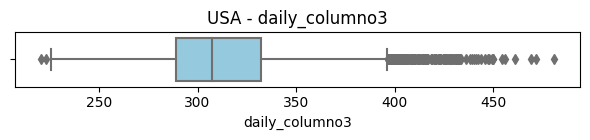


📦 Outlier detection for: CAN


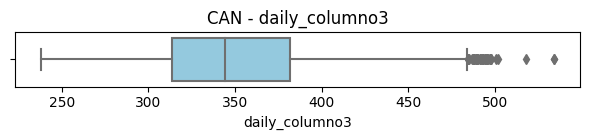


📦 Outlier detection for: BRA


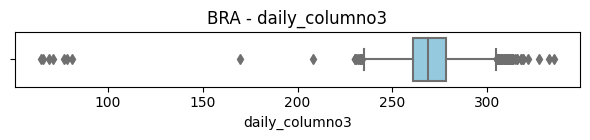


📦 Outlier detection for: ARG


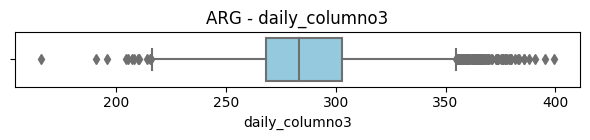


📦 Outlier detection for: AUS


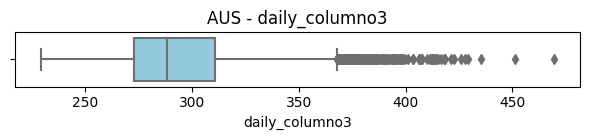


📦 Outlier detection for: NZL


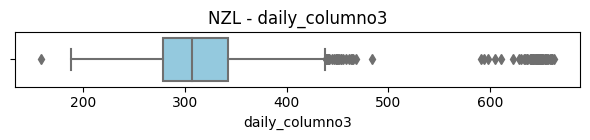


📦 Outlier detection for: IND


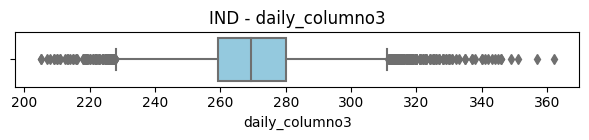


📦 Outlier detection for: CHN


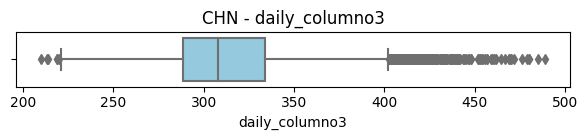


📦 Outlier detection for: MEX


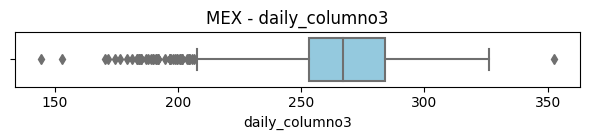


📦 Outlier detection for: ATA


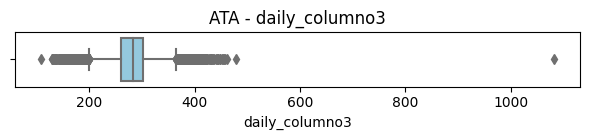


📦 Outlier detection for: ASM


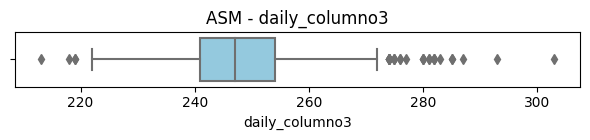


📦 Outlier detection for: GRL


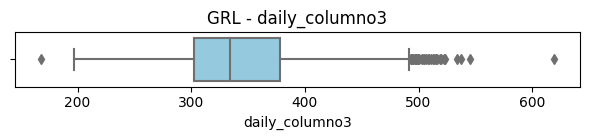

In [14]:
country_dfs = {
    'USA': usa_df,
    'CAN': can_df,
    'BRA': bra_df,
    'ARG': arg_df,
    'AUS': aus_df,
    'NZL': nzl_df,
    'IND': ind_df,
    'CHN': chn_df,
    'MEX': mexo_df,
    'ATA': ata_df,
    'ASM': asm_df,
    'GRL': grl_df,
}

# Loop through each DataFrame
for country, df in country_dfs.items():
    print(f"\n📦 Outlier detection for: {country}")
    numeric_cols = df.select_dtypes(include="number").columns

    for col in numeric_cols:
        plt.figure(figsize=(6, 1.5))
        sns.boxplot(data=df, x=col, color="skyblue")
        plt.title(f"{country} - {col}")
        plt.tight_layout()
        plt.show()

In [15]:


country_dfs = {
    'USA': usa_df,
    'CAN': can_df,
    'BRA': bra_df,
    'ARG': arg_df,
    'AUS': aus_df,
    'NZL': nzl_df,
    'IND': ind_df,
    'CHN': chn_df,
    'MEX': mexo_df,
    'ATA': ata_df,
    'ASM': asm_df,
    'GRL': grl_df,
}

# Function to calculate whiskers
def calculate_whiskers(col):
    q1, q3 = np.percentile(col.dropna(), [25, 75])
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return lower, upper

# Outlier treatment: clip to whisker bounds
for name, df in country_dfs.items():
    print(f"\n🛠️ Treating outliers for: {name}")
    numeric_cols = df.select_dtypes(include='number').columns

    for col in numeric_cols:
        lower, upper = calculate_whiskers(df[col])
        original_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
        print(f"   - {col}: {original_outliers} outliers clipped")

        # Clip values to lower and upper bounds
        df[col] = df[col].clip(lower=lower, upper=upper)

    # Replace in the dictionary
    country_dfs[name] = df



🛠️ Treating outliers for: USA
   - daily_columno3: 197 outliers clipped

🛠️ Treating outliers for: CAN
   - daily_columno3: 42 outliers clipped

🛠️ Treating outliers for: BRA
   - daily_columno3: 102 outliers clipped

🛠️ Treating outliers for: ARG
   - daily_columno3: 145 outliers clipped

🛠️ Treating outliers for: AUS
   - daily_columno3: 200 outliers clipped

🛠️ Treating outliers for: NZL
   - daily_columno3: 75 outliers clipped

🛠️ Treating outliers for: IND
   - daily_columno3: 280 outliers clipped

🛠️ Treating outliers for: CHN
   - daily_columno3: 287 outliers clipped

🛠️ Treating outliers for: MEX
   - daily_columno3: 51 outliers clipped

🛠️ Treating outliers for: ATA
   - daily_columno3: 1631 outliers clipped

🛠️ Treating outliers for: ASM
   - daily_columno3: 31 outliers clipped

🛠️ Treating outliers for: GRL
   - daily_columno3: 39 outliers clipped


In [16]:
# Loop through each dataset
for name, df in country_dfs.items():
    print(f"\n📊 Checking dataset: {name}")
    print("=" * 40)

    # Missing Values
    print("🔍 Missing Values:")
    print(df.isnull().sum())
    print("\n📉 Percentage of Missing Values:")
    print((df.isnull().sum() / df.shape[0] * 100).round(2))
    print("*" * 30)

    # Duplicates
    print(f"🧩 Duplicates: {df.duplicated().sum()}")
    print("*" * 30)

    # Garbage Values in object columns
    object_cols = df.select_dtypes(include='object').columns
    if len(object_cols) > 0:
        print("🗑️ Garbage (Unexpected) Values in Object Columns:")
        for col in object_cols:
            print(f"\n🔸 Column: {col}")
            print(df[col].value_counts(dropna=False))
    else:
        print("✅ No object (text) columns to check for garbage.")
    
    print("=" * 40)



📊 Checking dataset: USA
🔍 Missing Values:
daily_date        0
daily_columno3    0
dtype: int64

📉 Percentage of Missing Values:
daily_date        0.0
daily_columno3    0.0
dtype: float64
******************************
🧩 Duplicates: 0
******************************
🗑️ Garbage (Unexpected) Values in Object Columns:

🔸 Column: daily_date
2011-12-23T00:00:00Z    1
1989-12-12T00:00:00Z    1
1966-09-22T00:00:00Z    1
1971-08-28T00:00:00Z    1
2017-03-24T00:00:00Z    1
                       ..
1996-12-25T00:00:00Z    1
2000-11-13T00:00:00Z    1
1989-02-27T00:00:00Z    1
1984-09-24T00:00:00Z    1
1968-10-30T00:00:00Z    1
Name: daily_date, Length: 23639, dtype: int64

📊 Checking dataset: CAN
🔍 Missing Values:
daily_date        0
daily_columno3    0
dtype: int64

📉 Percentage of Missing Values:
daily_date        0.0
daily_columno3    0.0
dtype: float64
******************************
🧩 Duplicates: 0
******************************
🗑️ Garbage (Unexpected) Values in Object Columns:

🔸 Column: dai

**Checking For Outliers Again**

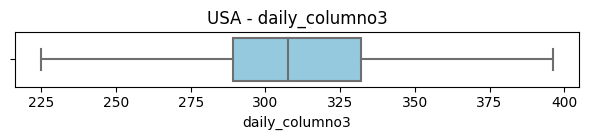

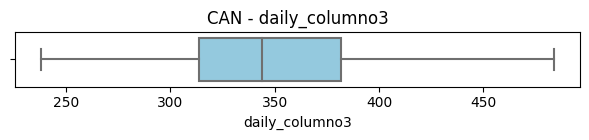

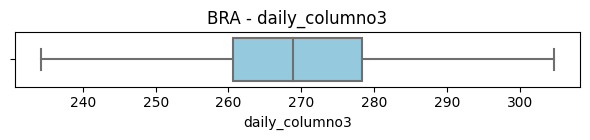

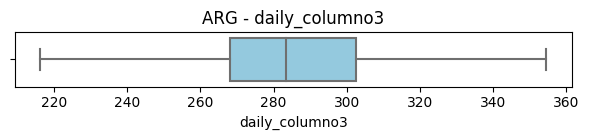

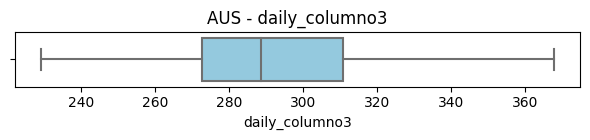

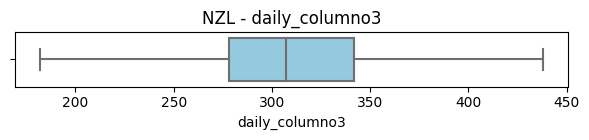

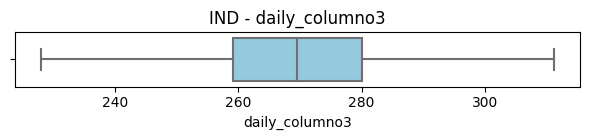

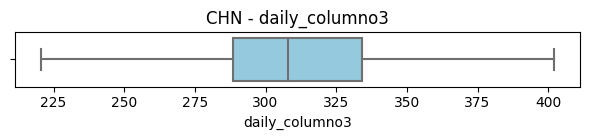

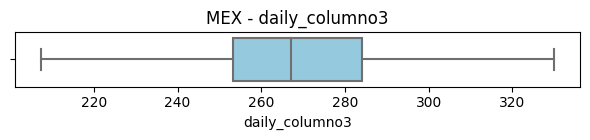

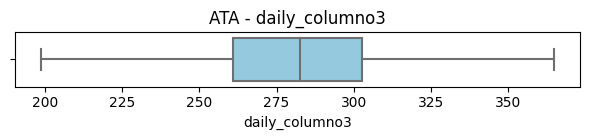

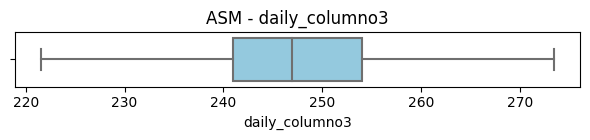

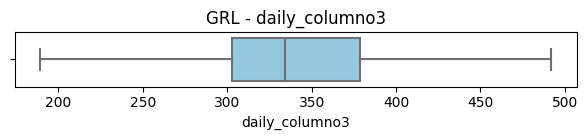

In [17]:
country_dfs = {
    'USA': usa_df,
    'CAN': can_df,
    'BRA': bra_df,
    'ARG': arg_df,
    'AUS': aus_df,
    'NZL': nzl_df,
    'IND': ind_df,
    'CHN': chn_df,
    'MEX': mexo_df,
    'ATA': ata_df,
    'ASM': asm_df,
    'GRL': grl_df,
}
# Loop through each DataFrame
for country, df in country_dfs.items():
    numeric_cols = df.select_dtypes(include="number").columns

    for col in numeric_cols:
        plt.figure(figsize=(6, 1.5))
        sns.boxplot(data=df, x=col, color="skyblue")
        plt.title(f"{country} - {col}")
        plt.tight_layout()
        plt.show()

*Creating Lag Features of 15 days, Rolling Average of past 10 days, Exponential Average of past 10 days,Rolling Standard Deviation of past 10 days,Exponential Standard Deviation of past 10 days*

In [18]:

usa_df['rolling_avg'] = usa_df['daily_columno3'].shift(1).rolling(window=10).mean().bfill()
usa_df['rolling_std'] = usa_df['daily_columno3'].shift(1).rolling(window=10).std().bfill()
usa_df['ewm_avg'] = usa_df['daily_columno3'].shift(1).ewm(span=10).mean().bfill()
usa_df['ewm_std'] = usa_df['daily_columno3'].shift(1).ewm(span=10).std().bfill()
for i in range(1, 16):
  usa_df[f'lag{i}'] = usa_df['daily_columno3'].shift(i)

usa_df.dropna(inplace=True)

can_df['rolling_avg'] = can_df['daily_columno3'].shift(1).rolling(window=10).mean().bfill()
can_df['rolling_std'] = can_df['daily_columno3'].shift(1).rolling(window=10).std().bfill()
can_df['ewm_avg'] = can_df['daily_columno3'].shift(1).ewm(span=10).mean().bfill()
can_df['ewm_std'] = can_df['daily_columno3'].shift(1).ewm(span=10).std().bfill()
for i in range(1, 16):
    can_df[f'lag{i}'] = can_df['daily_columno3'].shift(i)
can_df.dropna(inplace=True)


bra_df['rolling_avg'] = bra_df['daily_columno3'].shift(1).rolling(window=10).mean().bfill()
bra_df['rolling_std'] = bra_df['daily_columno3'].shift(1).rolling(window=10).std().bfill()
bra_df['ewm_avg'] = bra_df['daily_columno3'].shift(1).ewm(span=10).mean().bfill()
bra_df['ewm_std'] = bra_df['daily_columno3'].shift(1).ewm(span=10).std().bfill()
for i in range(1, 16):
    bra_df[f'lag{i}'] = bra_df['daily_columno3'].shift(i)
bra_df.dropna(inplace=True)


arg_df['rolling_avg'] = arg_df['daily_columno3'].shift(1).rolling(window=10).mean().bfill()
arg_df['rolling_std'] = arg_df['daily_columno3'].shift(1).rolling(window=10).std().bfill()
arg_df['ewm_avg'] = arg_df['daily_columno3'].shift(1).ewm(span=10).mean().bfill()
arg_df['ewm_std'] = arg_df['daily_columno3'].shift(1).ewm(span=10).std().bfill()
for i in range(1, 16):
    arg_df[f'lag{i}'] = arg_df['daily_columno3'].shift(i)
arg_df.dropna(inplace=True)

aus_df['rolling_avg'] = aus_df['daily_columno3'].shift(1).rolling(window=10).mean().bfill()
aus_df['rolling_std'] = aus_df['daily_columno3'].shift(1).rolling(window=10).std().bfill()
aus_df['ewm_avg'] = aus_df['daily_columno3'].shift(1).ewm(span=10).mean().bfill()
aus_df['ewm_std'] = aus_df['daily_columno3'].shift(1).ewm(span=10).std().bfill()
for i in range(1, 16):
    aus_df[f'lag{i}'] = aus_df['daily_columno3'].shift(i)   
aus_df.dropna(inplace=True)

nzl_df['rolling_avg'] = nzl_df['daily_columno3'].shift(1).rolling(window=10).mean().bfill()
nzl_df['rolling_std'] = nzl_df['daily_columno3'].shift(1).rolling(window=10).std().bfill()
nzl_df['ewm_avg'] = nzl_df['daily_columno3'].shift(1).ewm(span=10).mean().bfill()
nzl_df['ewm_std'] = nzl_df['daily_columno3'].shift(1).ewm(span=10).std().bfill()
for i in range(1, 16):
    nzl_df[f'lag{i}'] = nzl_df['daily_columno3'].shift(i)
nzl_df.dropna(inplace=True)

ind_df['rolling_avg'] = ind_df['daily_columno3'].shift(1).rolling(window=10).mean().bfill()
ind_df['rolling_std'] = ind_df['daily_columno3'].shift(1).rolling(window=10).std().bfill()
ind_df['ewm_avg'] = ind_df['daily_columno3'].shift(1).ewm(span=10).mean().bfill()
ind_df['ewm_std'] = ind_df['daily_columno3'].shift(1).ewm(span=10).std().bfill()
for i in range(1, 16):
    ind_df[f'lag{i}'] = ind_df['daily_columno3'].shift(i)
ind_df.dropna(inplace=True)

chn_df['rolling_avg'] = chn_df['daily_columno3'].shift(1).rolling(window=10).mean().bfill()
chn_df['rolling_std'] = chn_df['daily_columno3'].shift(1).rolling(window=10).std().bfill()
chn_df['ewm_avg'] = chn_df['daily_columno3'].shift(1).ewm(span=10).mean().bfill()
chn_df['ewm_std'] = chn_df['daily_columno3'].shift(1).ewm(span=10).std().bfill()
for i in range(1, 16):
    chn_df[f'lag{i}'] = chn_df['daily_columno3'].shift(i)   
chn_df.dropna(inplace=True)

mexo_df['rolling_avg'] = mexo_df['daily_columno3'].shift(1).rolling(window=10).mean().bfill()
mexo_df['rolling_std'] = mexo_df['daily_columno3'].shift(1).rolling(window=10).std().bfill()
mexo_df['ewm_avg'] = mexo_df['daily_columno3'].shift(1).ewm(span=10).mean().bfill()
mexo_df['ewm_std'] = mexo_df['daily_columno3'].shift(1).ewm(span=10).std().bfill()
for i in range(1, 16):
    mexo_df[f'lag{i}'] = mexo_df['daily_columno3'].shift(i)
mexo_df.dropna(inplace=True)

ata_df['rolling_avg'] = ata_df['daily_columno3'].shift(1).rolling(window=10).mean().bfill()
ata_df['rolling_std'] = ata_df['daily_columno3'].shift(1).rolling(window=10).std().bfill()
ata_df['ewm_avg'] = ata_df['daily_columno3'].shift(1).ewm(span=10).mean().bfill()
ata_df['ewm_std'] = ata_df['daily_columno3'].shift(1).ewm(span=10).std().bfill()
for i in range(1, 16):
    ata_df[f'lag{i}'] = ata_df['daily_columno3'].shift(i)
ata_df.dropna(inplace=True)


asm_df['rolling_avg'] = asm_df['daily_columno3'].shift(1).rolling(window=10).mean().bfill()
asm_df['rolling_std'] = asm_df['daily_columno3'].shift(1).rolling(window=10).std().bfill()
asm_df['ewm_avg'] = asm_df['daily_columno3'].shift(1).ewm(span=10).mean().bfill()
asm_df['ewm_std'] = asm_df['daily_columno3'].shift(1).ewm(span=10).std().bfill()
for i in range(1, 16):
    asm_df[f'lag{i}'] = asm_df['daily_columno3'].shift(i)
asm_df.dropna(inplace=True)



grl_df['rolling_avg'] = grl_df['daily_columno3'].shift(1).rolling(window=10).mean().bfill()
grl_df['rolling_std'] = grl_df['daily_columno3'].shift(1).rolling(window=10).std().bfill()
grl_df['ewm_avg'] = grl_df['daily_columno3'].shift(1).ewm(span=10).mean().bfill()
grl_df['ewm_std'] = grl_df['daily_columno3'].shift(1).ewm(span=10).std().bfill()
for i in range(1, 16):
    grl_df[f'lag{i}'] = grl_df['daily_columno3'].shift(i)
grl_df.dropna(inplace=True)




In [19]:
# Create a dictionary to hold the DataFrames for each country
country_cfs = {
    'USA': usa_df,
    'CAN': can_df,
    'BRA': bra_df,
    'ARG': arg_df,
    'AUS': aus_df,
    'NZL': nzl_df,
    'IND': ind_df,
    'CHN': chn_df,
    'MEX': mexo_df,
    'ATA': ata_df,
    'ASM': asm_df,
    'GRL': grl_df,
}

# Define features to use in the model
features = ['rolling_avg', 'rolling_std', 'ewm_avg', 'ewm_std'] + [f'lag{i}' for i in range(1, 16)]

# Define models
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'Support Vector Regressor': SVR(),
    'AdaBoost Regressor': AdaBoostRegressor(n_estimators=50, random_state=42),
    'MLP Regressor': MLPRegressor(hidden_layer_sizes=(50,), max_iter=500, random_state=42),
    'K-Neighbors Regressor': KNeighborsRegressor(n_neighbors=3)
}

# Store results and splits
eval_results = []
data_splits = {}  # Store splits per country

for country, cf in country_cfs.items():
    print(f"\n🌍 Running models for: {country}")

    # Prepare data
    X = cf[features]
    y = cf['daily_columno3']

    # Scale features and target
    scaler_x = MinMaxScaler()
    scaler_y = MinMaxScaler()

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

    X_train_scaled = scaler_x.fit_transform(X_train)
    X_test_scaled = scaler_x.transform(X_test)
    y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).flatten()
    y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1)).flatten()

    # Save the splits for reuse later
    data_splits[country] = {
        'X_train': X_train_scaled,
        'X_test': X_test_scaled,
        'y_train': y_train_scaled,
        'y_test': y_test_scaled,
        'scaler_x': scaler_x,
        'scaler_y': scaler_y
    }

    for model_name, model in models.items():
        print(f"   🔧 Training: {model_name}")
        model.fit(X_train_scaled, y_train_scaled)
        y_pred = model.predict(X_test_scaled)

        # Evaluation
        rmse = mean_squared_error(y_test_scaled, y_pred, squared=False)
        mae = mean_absolute_error(y_test_scaled, y_pred)
        r2 = r2_score(y_test_scaled, y_pred)

        eval_results.append({
            'Country': country,
            'Model': model_name,
            'RMSE': rmse,
            'MAE': mae,
            'R2': r2 * 100
        })
        print()

# Convert results to DataFrame
results_df = pd.DataFrame(eval_results).sort_values(['Country', 'RMSE'])

# Display
print("\n📊 Evaluation Summary (sorted by country and RMSE):")
for country in results_df['Country'].unique():
    print(f"\nResults for {country}:")
    country_results = results_df[results_df['Country'] == country]
    print(country_results[['Model', 'RMSE', 'MAE', 'R2']])



🌍 Running models for: USA
   🔧 Training: Linear Regression

   🔧 Training: Decision Tree

   🔧 Training: Random Forest

   🔧 Training: Gradient Boosting

   🔧 Training: Support Vector Regressor

   🔧 Training: AdaBoost Regressor

   🔧 Training: MLP Regressor

   🔧 Training: K-Neighbors Regressor


🌍 Running models for: CAN
   🔧 Training: Linear Regression

   🔧 Training: Decision Tree

   🔧 Training: Random Forest

   🔧 Training: Gradient Boosting

   🔧 Training: Support Vector Regressor

   🔧 Training: AdaBoost Regressor

   🔧 Training: MLP Regressor

   🔧 Training: K-Neighbors Regressor


🌍 Running models for: BRA
   🔧 Training: Linear Regression

   🔧 Training: Decision Tree

   🔧 Training: Random Forest

   🔧 Training: Gradient Boosting

   🔧 Training: Support Vector Regressor

   🔧 Training: AdaBoost Regressor

   🔧 Training: MLP Regressor

   🔧 Training: K-Neighbors Regressor


🌍 Running models for: ARG
   🔧 Training: Linear Regression

   🔧 Training: Decision Tree

   🔧 Trainin

**HyperParameter Tuning**

In [20]:
from collections import defaultdict


# -------------------- PARAM SPACES -------------------- #
param_spaces = {
    'Linear Regression': {},
    'Decision Tree': {
        'max_depth': ('int', 3, 10),
        'min_samples_split': ('int', 2, 10),
    },
    'Random Forest': {
        'n_estimators': ('int', 50, 200),
        'max_depth': ('int', 3, 10),
    },
    'Gradient Boosting': {
        'n_estimators': ('int', 50, 200),
        'learning_rate': ('float', 0.01, 0.3),
        'max_depth': ('int', 3, 7),
    },
    'SVR': {
        'C': ('float', 0.1, 10),
        'epsilon': ('float', 0.01, 1.0),
    },
    'AdaBoost Regressor': {
        'n_estimators': ('int', 50, 150),
        'learning_rate': ('float', 0.01, 1.0),
    },
    'MLP Regressor': {
        'hidden_layer_sizes': ('cat', [(50,), (100,), (50, 50)]),
        'alpha': ('float', 0.0001, 0.01),
        'learning_rate_init': ('float', 0.001, 0.05),
    },
    'K-Neighbors Regressor': {
        'n_neighbors': ('int', 2, 10),
    }
}

# -------------------- MODEL CLASSES -------------------- #
model_classes = {
    'Linear Regression': LinearRegression,
    'Decision Tree': DecisionTreeRegressor,
    'Random Forest': RandomForestRegressor,
    'Gradient Boosting': GradientBoostingRegressor,
    'SVR': SVR,
    'AdaBoost Regressor': AdaBoostRegressor,
    'MLP Regressor': MLPRegressor,
    'K-Neighbors Regressor': KNeighborsRegressor,
}

# -------------------- SUGGEST FUNCTION -------------------- #
def suggest(trial, name, dist):
    if dist[0] == 'int':
        return trial.suggest_int(name, *dist[1:])
    elif dist[0] == 'float':
        return trial.suggest_float(name, *dist[1:])
    elif dist[0] == 'cat':
        return trial.suggest_categorical(name, dist[1])
    else:
        raise ValueError(f"Unsupported distribution type for {name}: {dist}")

# -------------------- TUNING FUNCTION -------------------- #
def tune_model(name, model_class, param_space, X_train, y_train, X_test, y_test, n_trials=15):
    if not param_space:
        return model_class()

    def objective(trial):
        params = {key: suggest(trial, key, dist) for key, dist in param_space.items()}
        model = model_class(**params)
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        return mean_squared_error(y_test, preds)

    study = optuna.create_study(direction='minimize', sampler=TPESampler(seed=42))
    study.optimize(objective, n_trials=n_trials)
    return model_class(**study.best_params)

# -------------------- EVALUATION STORAGE -------------------- #
all_results = defaultdict(dict)

# -------------------- LOOP USING STORED SPLITS -------------------- #
for country in data_splits:
    print(f"\n🌍 Tuning models for: {country}")

    X_train = data_splits[country]['X_train']
    X_test = data_splits[country]['X_test']
    y_train = data_splits[country]['y_train']
    y_test = data_splits[country]['y_test']
    scaler_y = data_splits[country]['scaler_y']

    for name in model_classes:
        print(f"   🔧 Tuning: {name}")
        model = tune_model(
            name, model_classes[name],
            param_spaces.get(name, {}),
            X_train, y_train,
            X_test, y_test,
            n_trials=15
        )

        model.fit(X_train, y_train)
     
        preds = model.predict(X_test)
        mse = mean_squared_error(y_test, preds)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_test, preds)
        r2 = r2_score(y_test, preds)


        all_results[name][country] = {
            'RMSE': rmse,
            'MAE': mae,
            'R2': r2,
            'Actuals': y_test,
            'Predictions': preds
        }



[I 2025-07-17 21:38:02,615] A new study created in memory with name: no-name-0dfe2d16-4b66-4ea9-8d3f-d0a8ff23b710



🌍 Tuning models for: USA
   🔧 Tuning: Linear Regression
   🔧 Tuning: Decision Tree


[I 2025-07-17 21:38:02,915] Trial 0 finished with value: 0.00663458322891125 and parameters: {'max_depth': 5, 'min_samples_split': 10}. Best is trial 0 with value: 0.00663458322891125.
[I 2025-07-17 21:38:03,308] Trial 1 finished with value: 0.00799275797810673 and parameters: {'max_depth': 8, 'min_samples_split': 7}. Best is trial 0 with value: 0.00663458322891125.
[I 2025-07-17 21:38:03,422] Trial 2 finished with value: 0.006864167583764309 and parameters: {'max_depth': 4, 'min_samples_split': 3}. Best is trial 0 with value: 0.00663458322891125.
[I 2025-07-17 21:38:03,511] Trial 3 finished with value: 0.0078258554785741 and parameters: {'max_depth': 3, 'min_samples_split': 9}. Best is trial 0 with value: 0.00663458322891125.
[I 2025-07-17 21:38:03,693] Trial 4 finished with value: 0.007825118020454233 and parameters: {'max_depth': 7, 'min_samples_split': 8}. Best is trial 0 with value: 0.00663458322891125.
[I 2025-07-17 21:38:03,782] Trial 5 finished with value: 0.007825855478574116 

   🔧 Tuning: Random Forest


[I 2025-07-17 21:38:20,909] Trial 0 finished with value: 0.006411908180169563 and parameters: {'n_estimators': 106, 'max_depth': 10}. Best is trial 0 with value: 0.006411908180169563.
[I 2025-07-17 21:38:38,542] Trial 1 finished with value: 0.006334529460027316 and parameters: {'n_estimators': 160, 'max_depth': 7}. Best is trial 1 with value: 0.006334529460027316.
[I 2025-07-17 21:38:43,652] Trial 2 finished with value: 0.006653079039179933 and parameters: {'n_estimators': 73, 'max_depth': 4}. Best is trial 1 with value: 0.006334529460027316.
[I 2025-07-17 21:38:51,746] Trial 3 finished with value: 0.006427282772850671 and parameters: {'n_estimators': 58, 'max_depth': 9}. Best is trial 1 with value: 0.006334529460027316.
[I 2025-07-17 21:39:08,957] Trial 4 finished with value: 0.006324317319346658 and parameters: {'n_estimators': 140, 'max_depth': 8}. Best is trial 4 with value: 0.006324317319346658.
[I 2025-07-17 21:39:16,815] Trial 5 finished with value: 0.006453924877552102 and para

...

[I 2025-07-18 00:13:35,622] Trial 0 finished with value: 0.006419912420712516 and parameters: {'n_estimators': 87, 'learning_rate': 0.951207163345817}. Best is trial 0 with value: 0.006419912420712516.
[I 2025-07-18 00:13:37,340] Trial 1 finished with value: 0.006432984396052697 and parameters: {'n_estimators': 123, 'learning_rate': 0.6026718993550663}. Best is trial 0 with value: 0.006419912420712516.
[I 2025-07-18 00:13:38,935] Trial 2 finished with value: 0.005466304259394771 and parameters: {'n_estimators': 65, 'learning_rate': 0.16443457513284063}. Best is trial 2 with value: 0.005466304259394771.
[I 2025-07-18 00:13:39,826] Trial 3 finished with value: 0.0061731582910285005 and parameters: {'n_estimators': 55, 'learning_rate': 0.8675143843171859}. Best is trial 2 with value: 0.005466304259394771.
[I 2025-07-18 00:13:41,312] Trial 4 finished with value: 0.0065093716158138686 and parameters: {'n_estimators': 110, 'learning_rate': 0.710991852018085}. Best is trial 2 with value: 0.00

   🔧 Tuning: MLP Regressor


c:\Users\Abir Hossain\AppData\Local\Programs\Python\Python37\lib\site-packages\optuna\distributions.py:524: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (50,) which is of type tuple.
  warnings.warn(message)
c:\Users\Abir Hossain\AppData\Local\Programs\Python\Python37\lib\site-packages\optuna\distributions.py:524: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (100,) which is of type tuple.
  warnings.warn(message)
c:\Users\Abir Hossain\AppData\Local\Programs\Python\Python37\lib\site-packages\optuna\distributions.py:524: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (50, 50) which is of type tuple.
  warnings.warn(message)
[I 2025-07-18 00:14:11,010] Trial 0 finished with value: 0.004861661974891749 and param

   🔧 Tuning: K-Neighbors Regressor


[I 2025-07-18 00:14:21,085] Trial 1 finished with value: 0.006220621740606508 and parameters: {'n_neighbors': 10}. Best is trial 1 with value: 0.006220621740606508.
[I 2025-07-18 00:14:21,240] Trial 2 finished with value: 0.006339828959247065 and parameters: {'n_neighbors': 8}. Best is trial 1 with value: 0.006220621740606508.
[I 2025-07-18 00:14:21,424] Trial 3 finished with value: 0.006445791773556496 and parameters: {'n_neighbors': 7}. Best is trial 1 with value: 0.006220621740606508.
[I 2025-07-18 00:14:21,572] Trial 4 finished with value: 0.007278815861532357 and parameters: {'n_neighbors': 3}. Best is trial 1 with value: 0.006220621740606508.
[I 2025-07-18 00:14:21,738] Trial 5 finished with value: 0.007278815861532357 and parameters: {'n_neighbors': 3}. Best is trial 1 with value: 0.006220621740606508.
[I 2025-07-18 00:14:21,888] Trial 6 finished with value: 0.00834626775903643 and parameters: {'n_neighbors': 2}. Best is trial 1 with value: 0.006220621740606508.
[I 2025-07-18 00

In [21]:

# -------------------- PRINT FINAL SUMMARY -------------------- #
print("\n\n======= Final Model-wise Results Across Countries =======")
for name in model_classes:
    print(f"\n---- {name} ----")
    for country, metrics in all_results[name].items():
        print(f"{country}: MAE = {metrics['MAE']:.3f}, RMSE = {metrics['RMSE']:.3f}, R² = {metrics['R2'] * 100:.2f}%")



======= Final Model-wise Results Across Countries =======

---- Linear Regression ----
USA: MAE = 0.055, RMSE = 0.077, R² = 78.27%
CAN: MAE = 0.040, RMSE = 0.056, R² = 88.24%
BRA: MAE = 0.058, RMSE = 0.078, R² = 77.06%
ARG: MAE = 0.072, RMSE = 0.094, R² = 70.28%
AUS: MAE = 0.045, RMSE = 0.060, R² = 84.24%
NZL: MAE = 0.056, RMSE = 0.072, R² = 77.35%
IND: MAE = 0.095, RMSE = 0.132, R² = 68.82%
CHN: MAE = 0.066, RMSE = 0.091, R² = 75.27%
MEX: MAE = 0.042, RMSE = 0.054, R² = 85.18%
ATA: MAE = 0.060, RMSE = 0.088, R² = 83.94%
ASM: MAE = 0.104, RMSE = 0.130, R² = 59.92%
GRL: MAE = 0.048, RMSE = 0.069, R² = 83.26%

---- Decision Tree ----
USA: MAE = 0.059, RMSE = 0.081, R² = 75.87%
CAN: MAE = 0.041, RMSE = 0.058, R² = 87.55%
BRA: MAE = 0.060, RMSE = 0.080, R² = 75.95%
ARG: MAE = 0.075, RMSE = 0.098, R² = 67.92%
AUS: MAE = 0.047, RMSE = 0.062, R² = 83.23%
NZL: MAE = 0.057, RMSE = 0.075, R² = 75.22%
IND: MAE = 0.100, RMSE = 0.136, R² = 66.70%
CHN: MAE = 0.068, RMSE = 0.095, R² = 73.22%
MEX: M

**Actual Vs Expected**

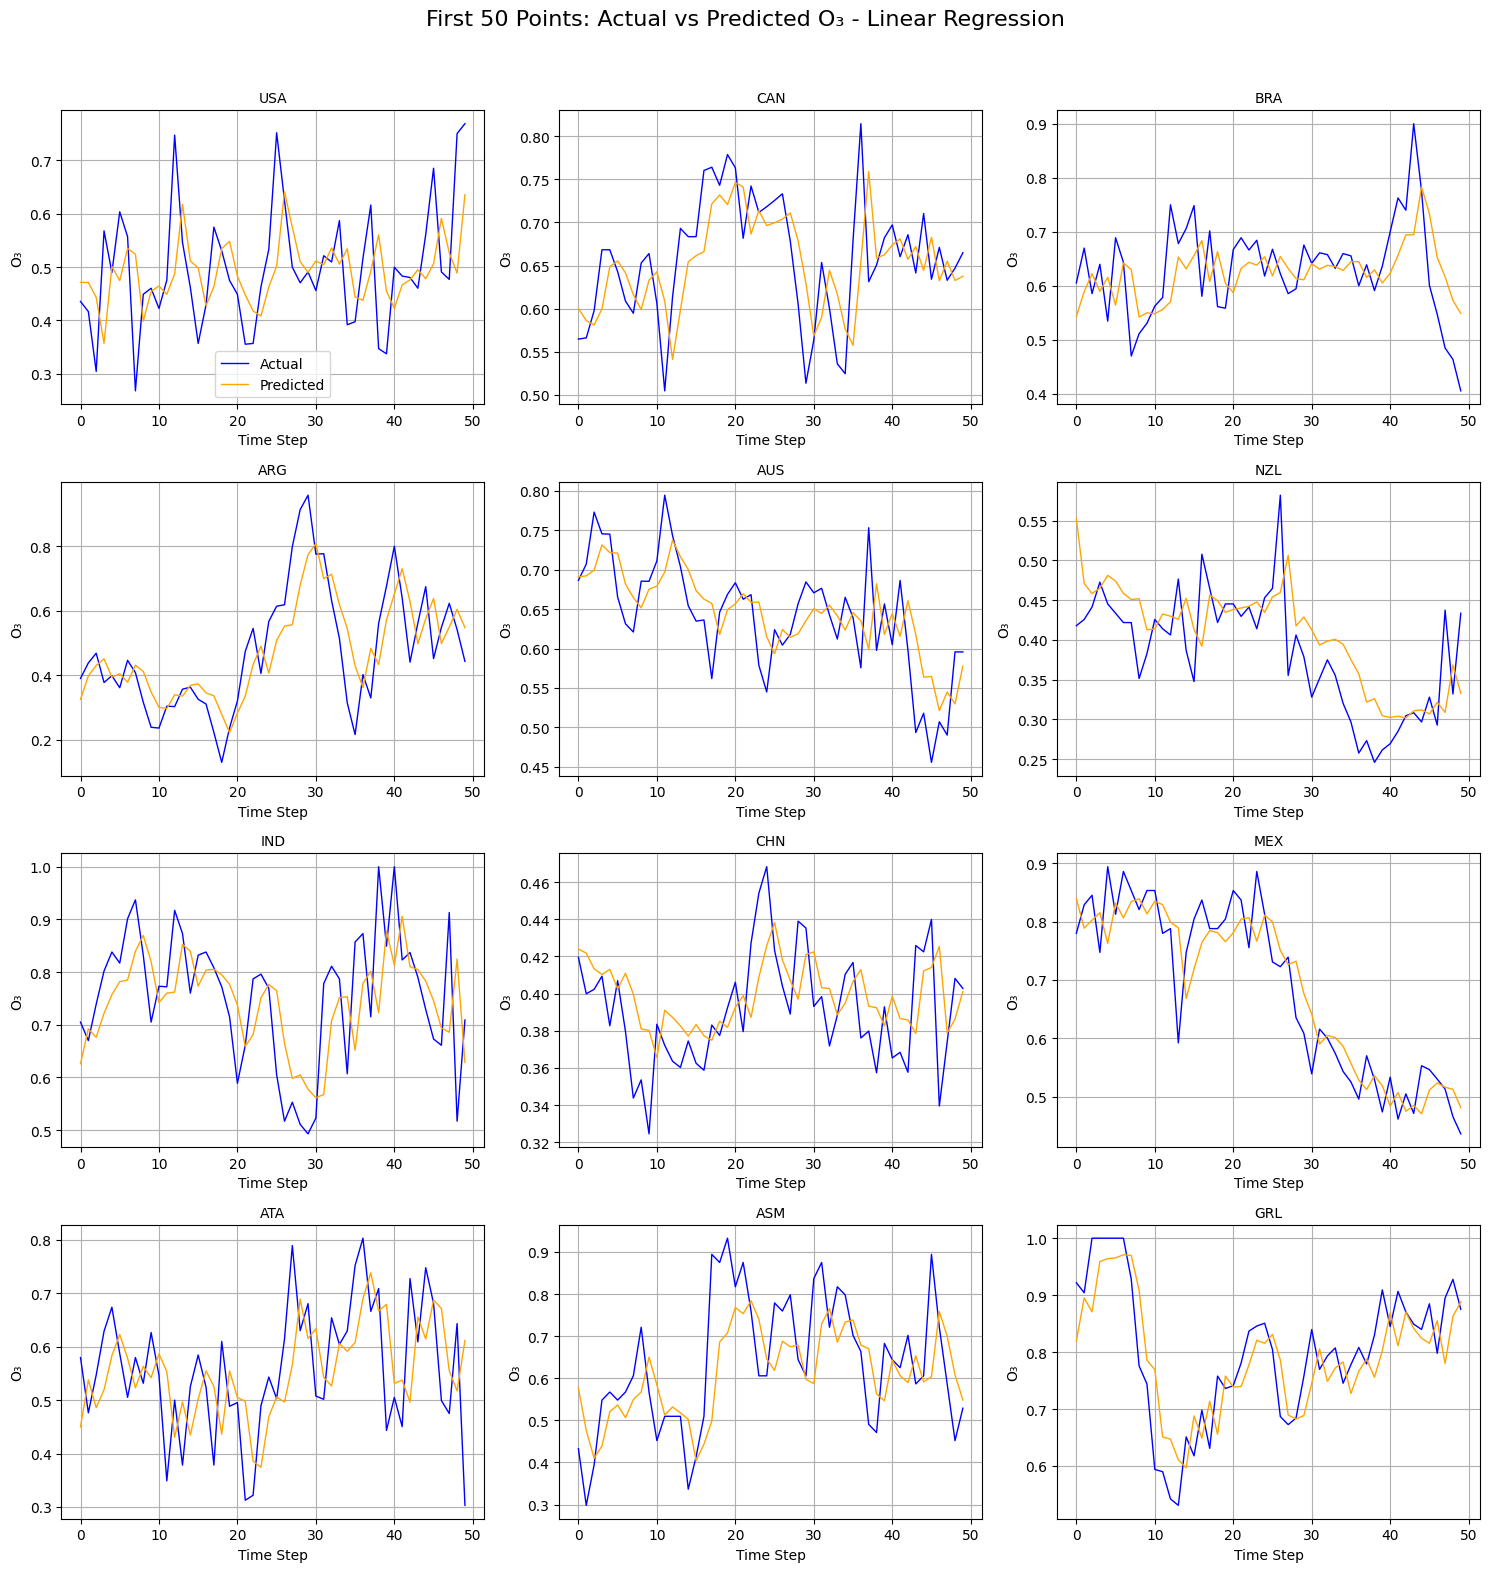

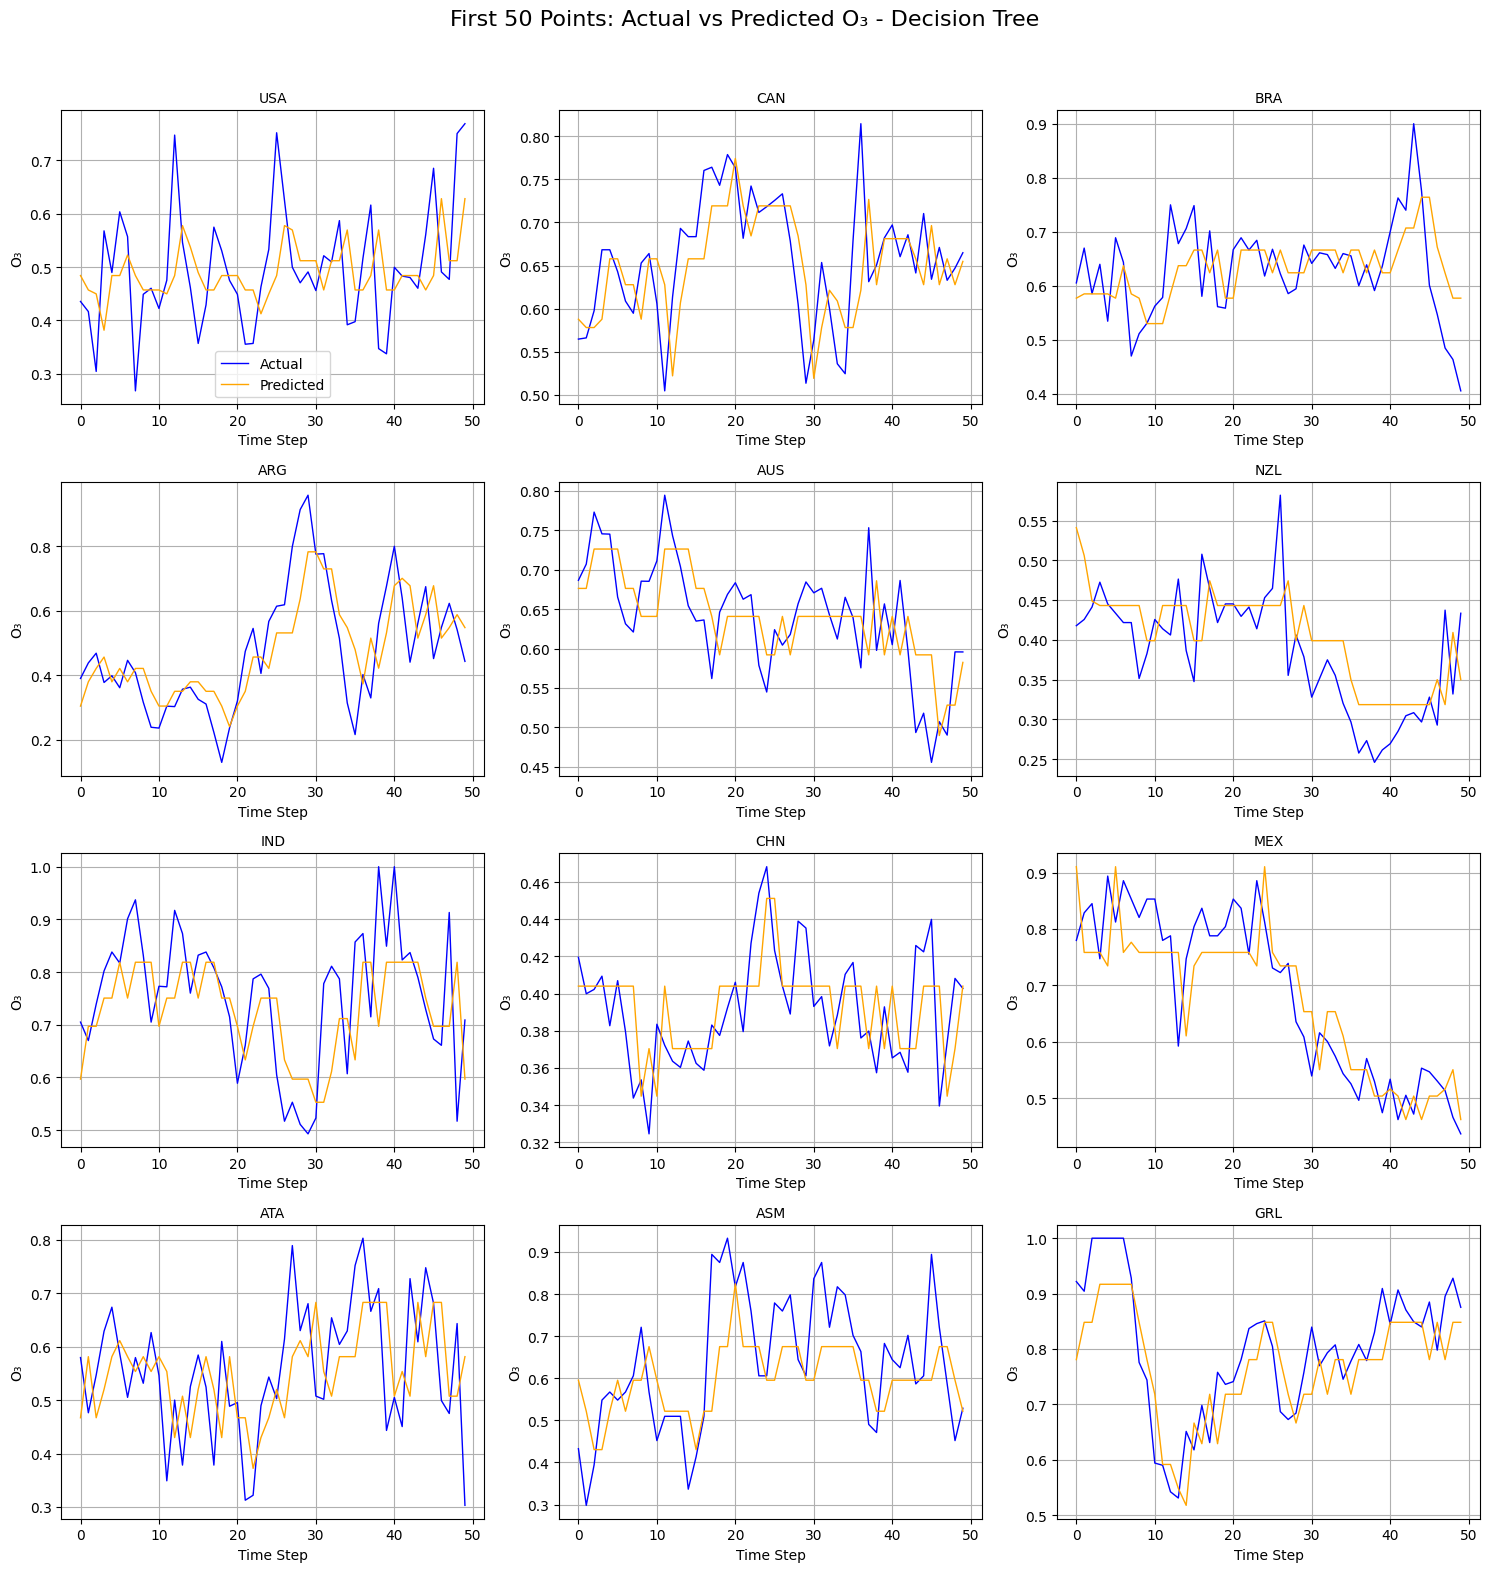

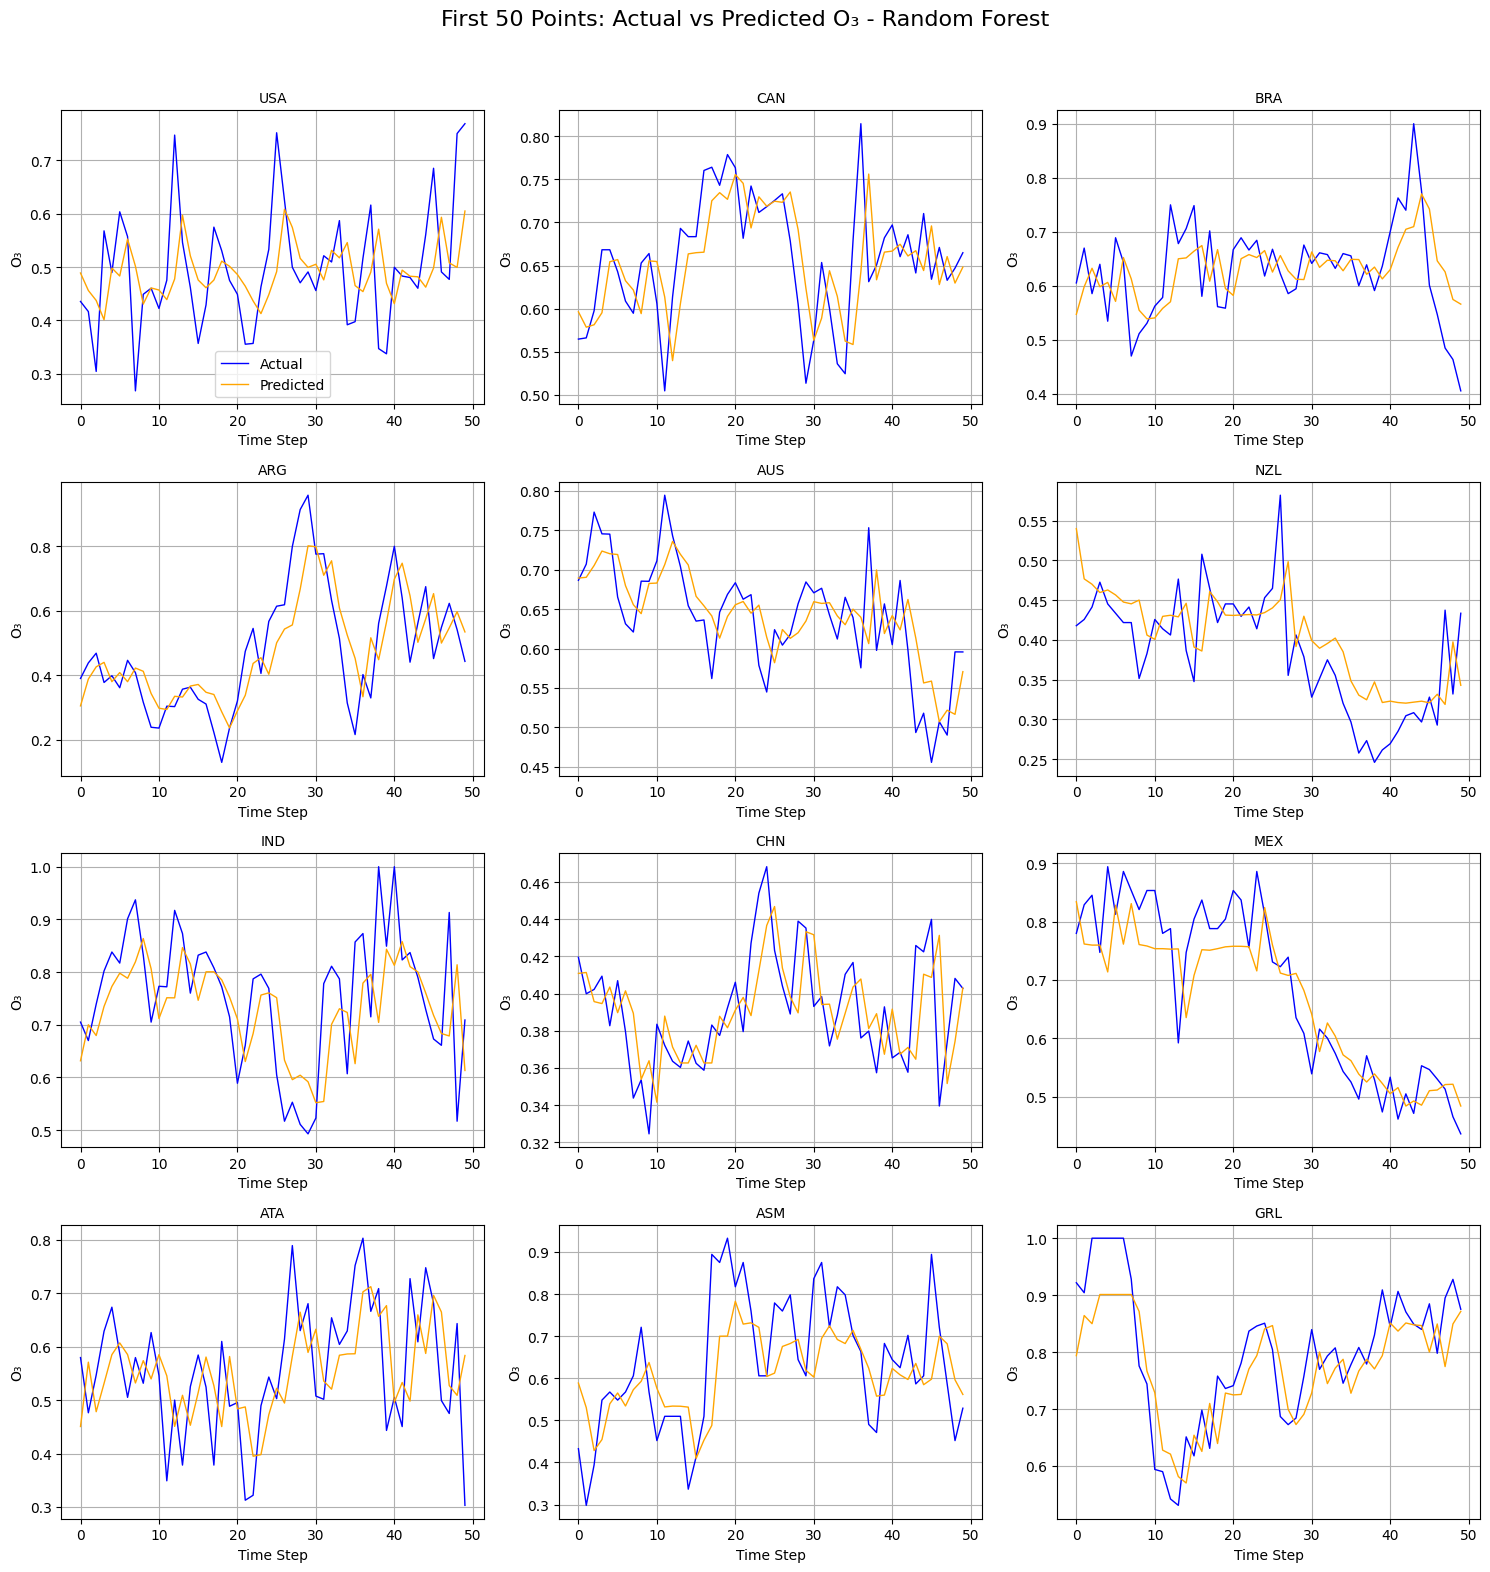

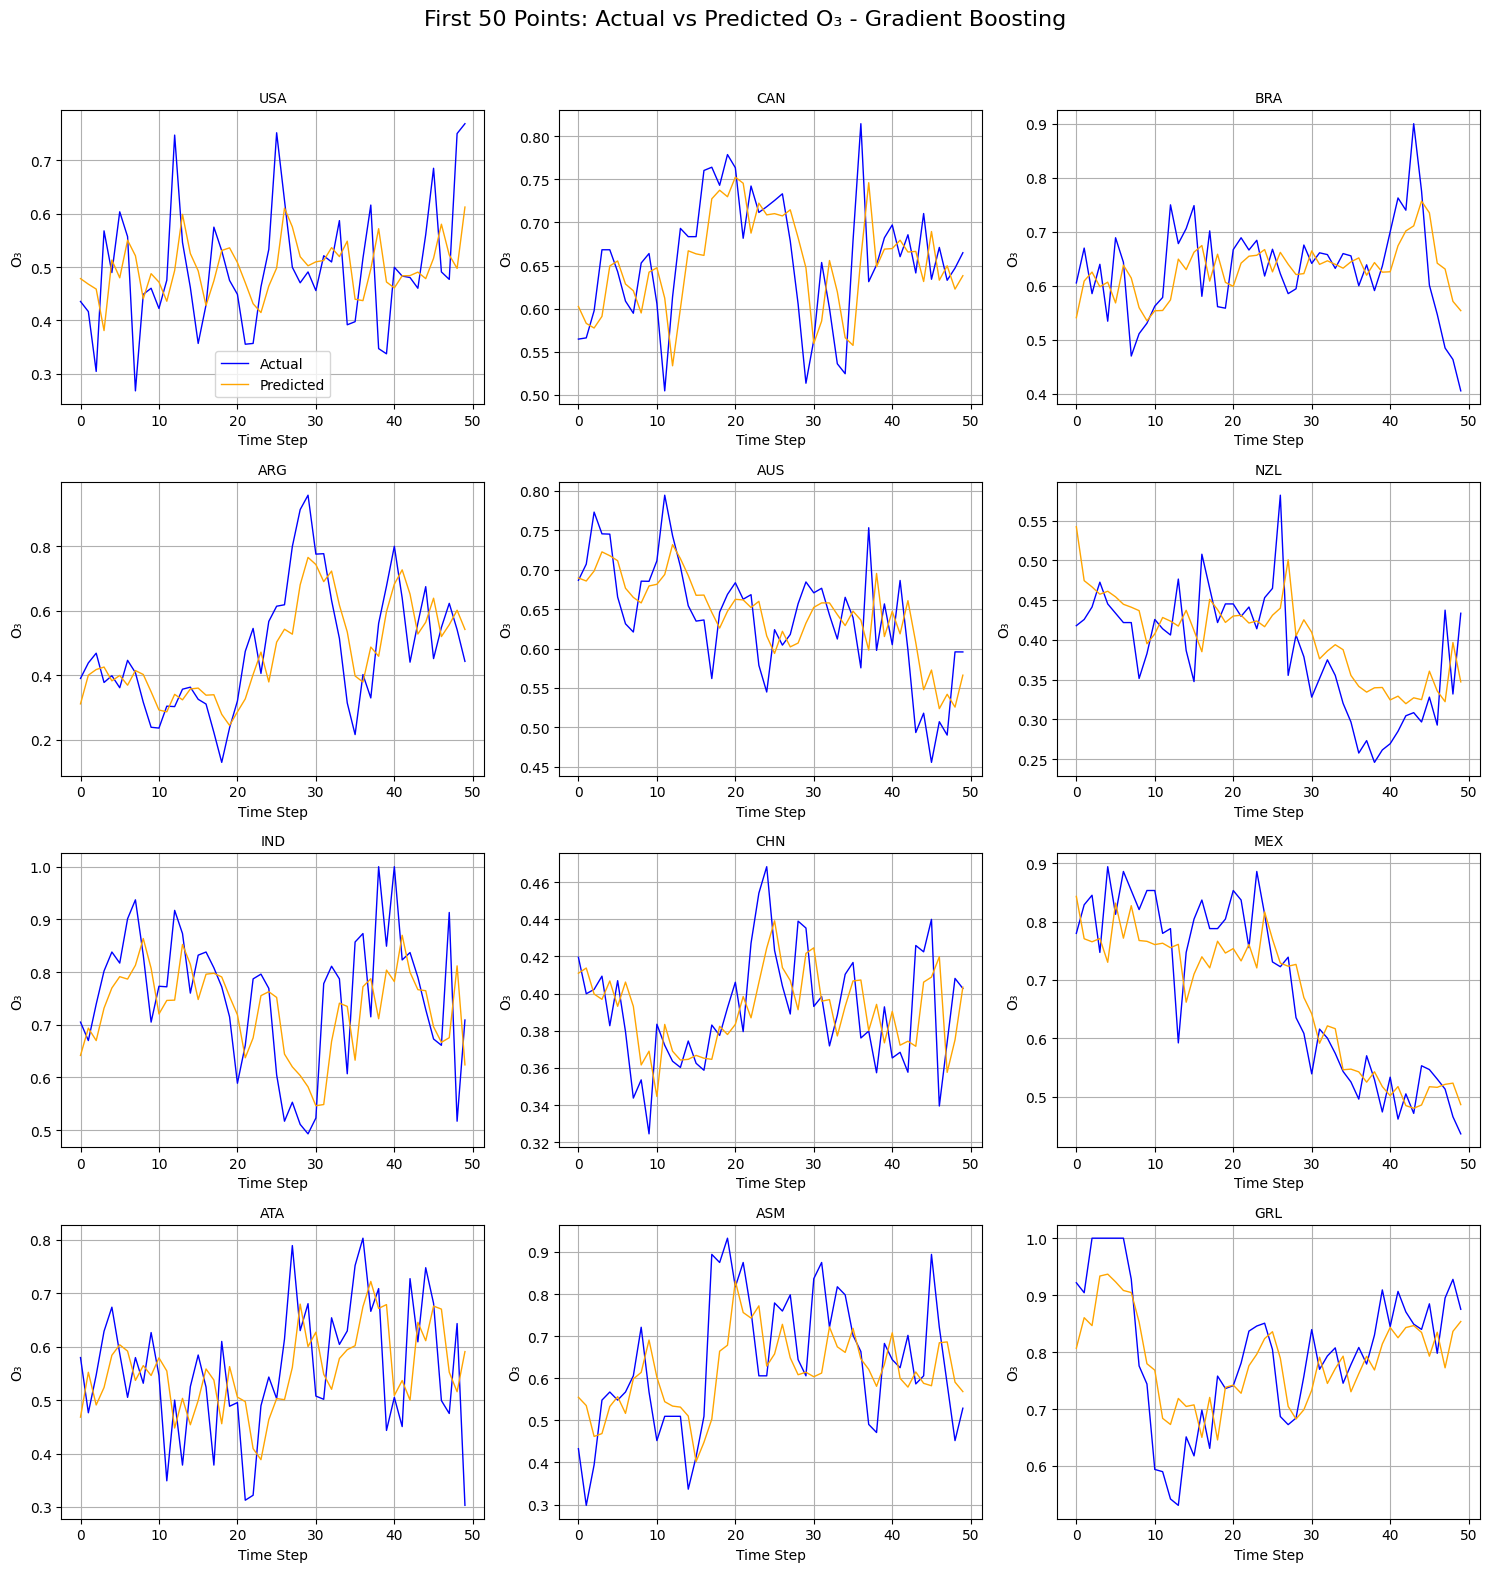

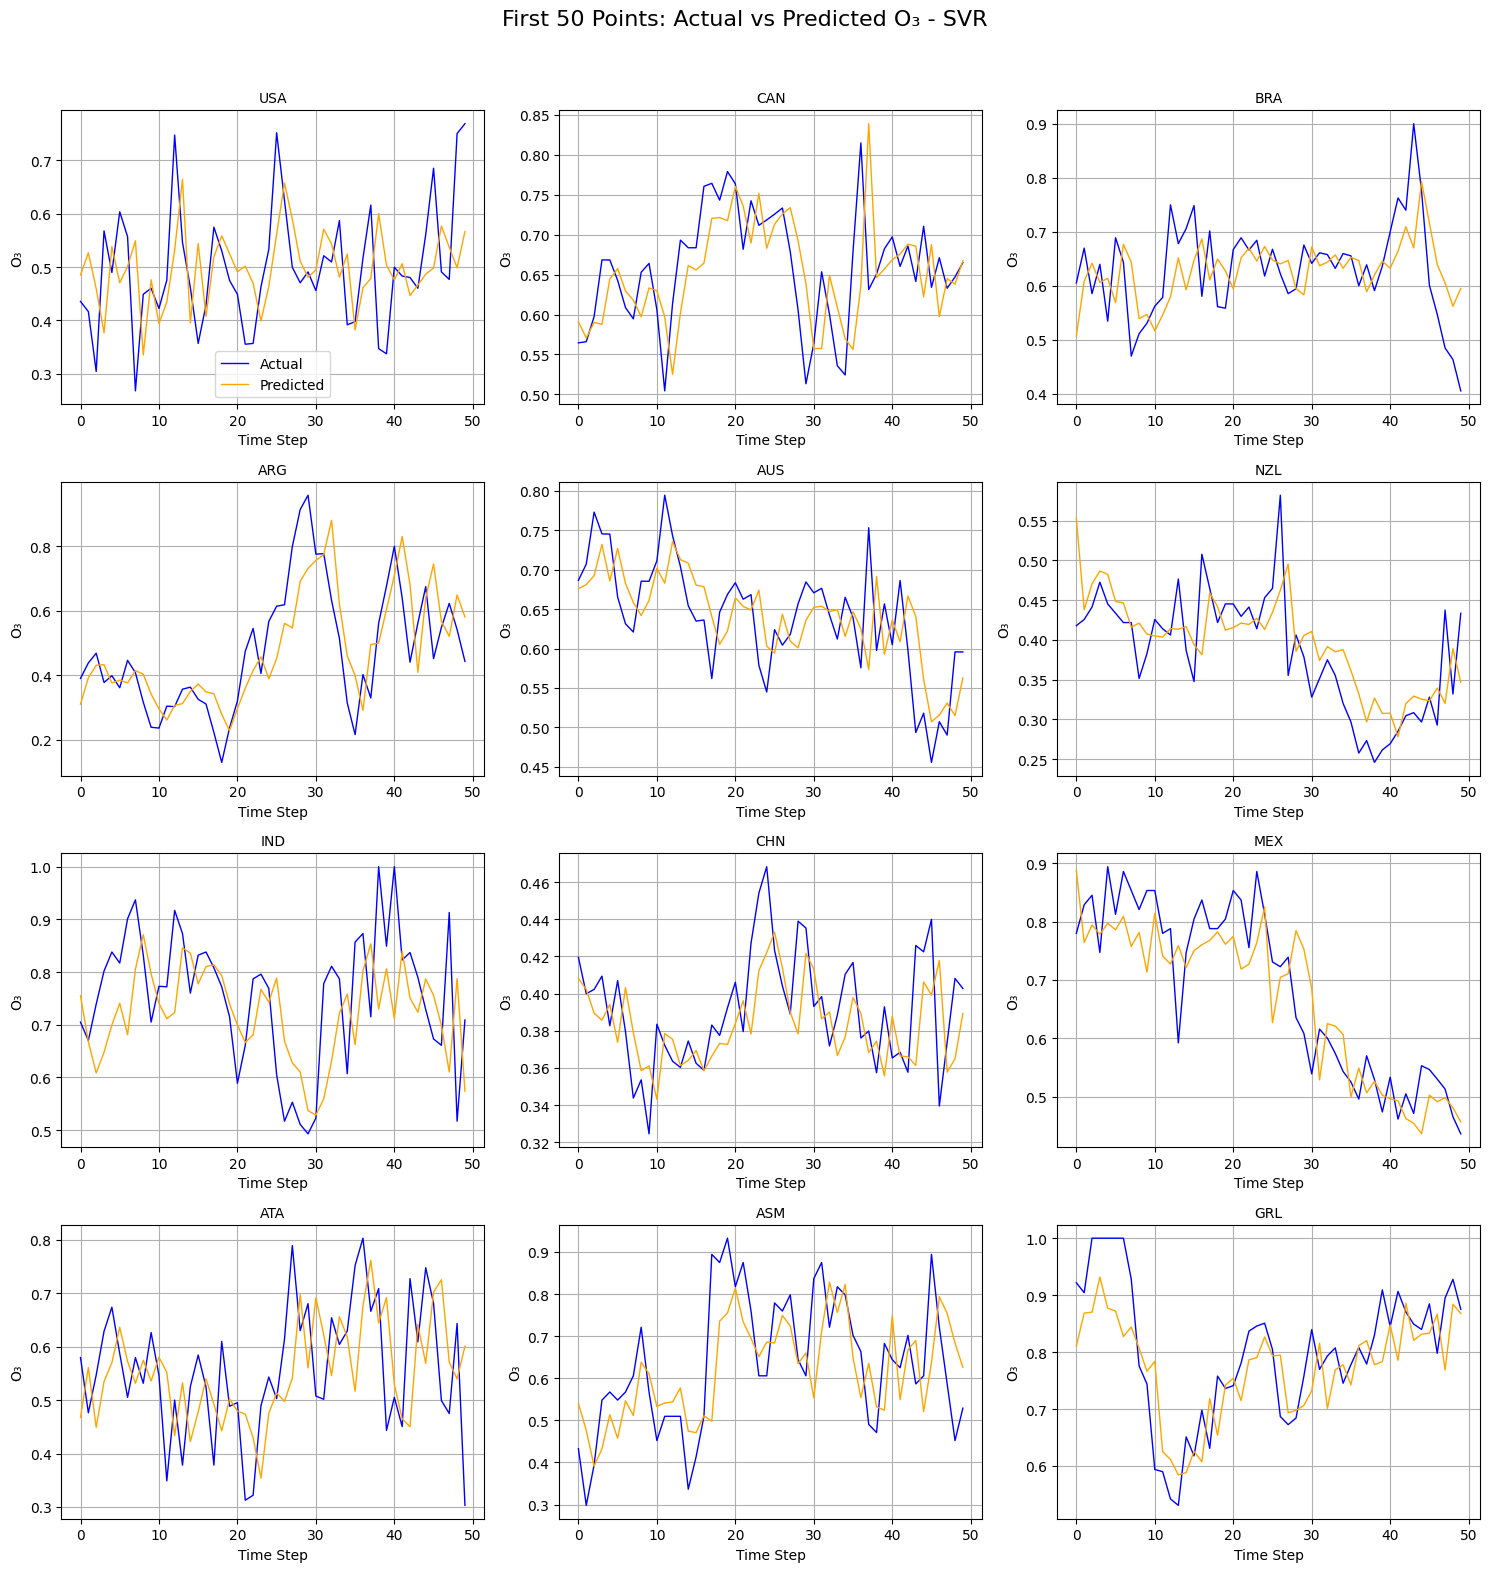

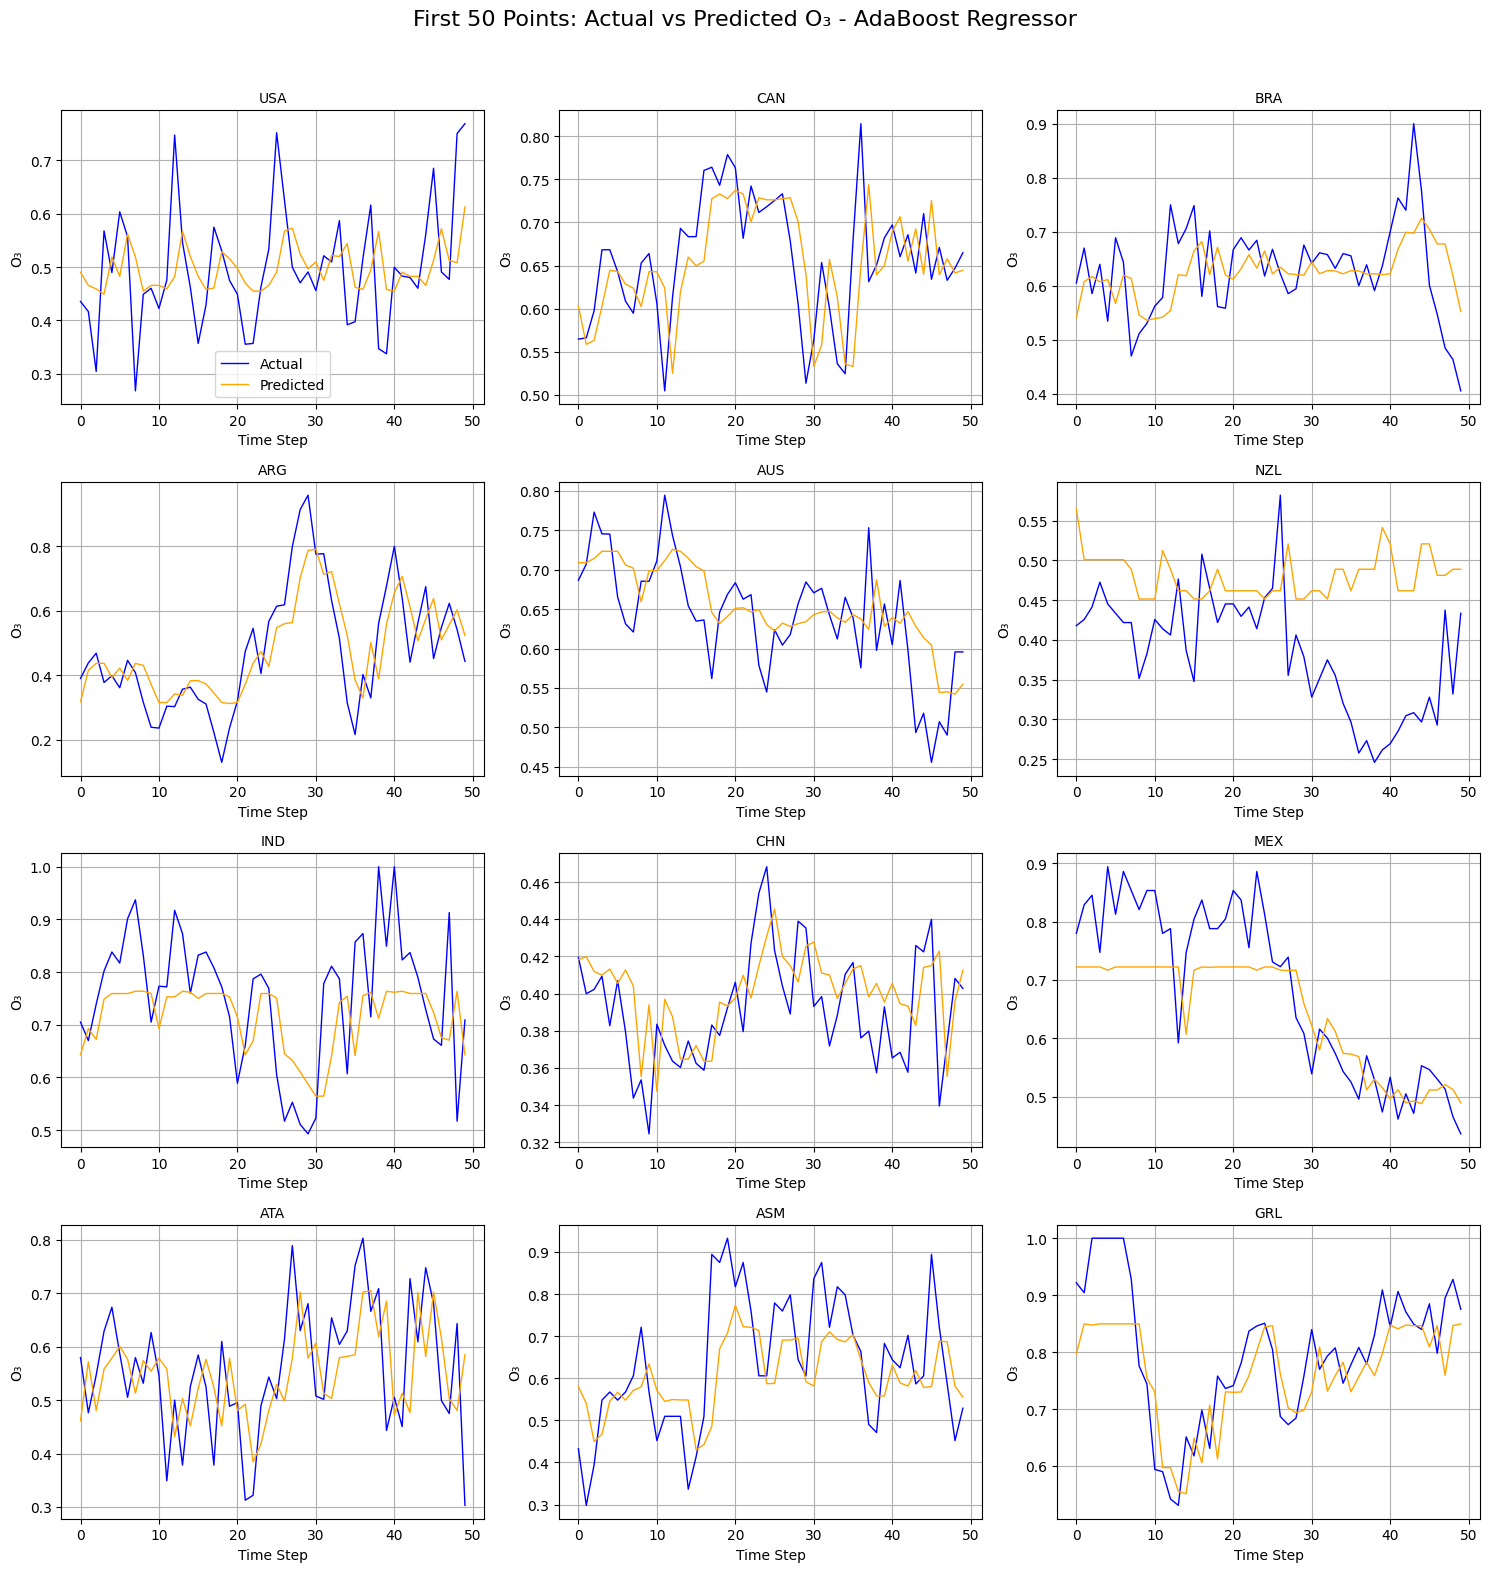

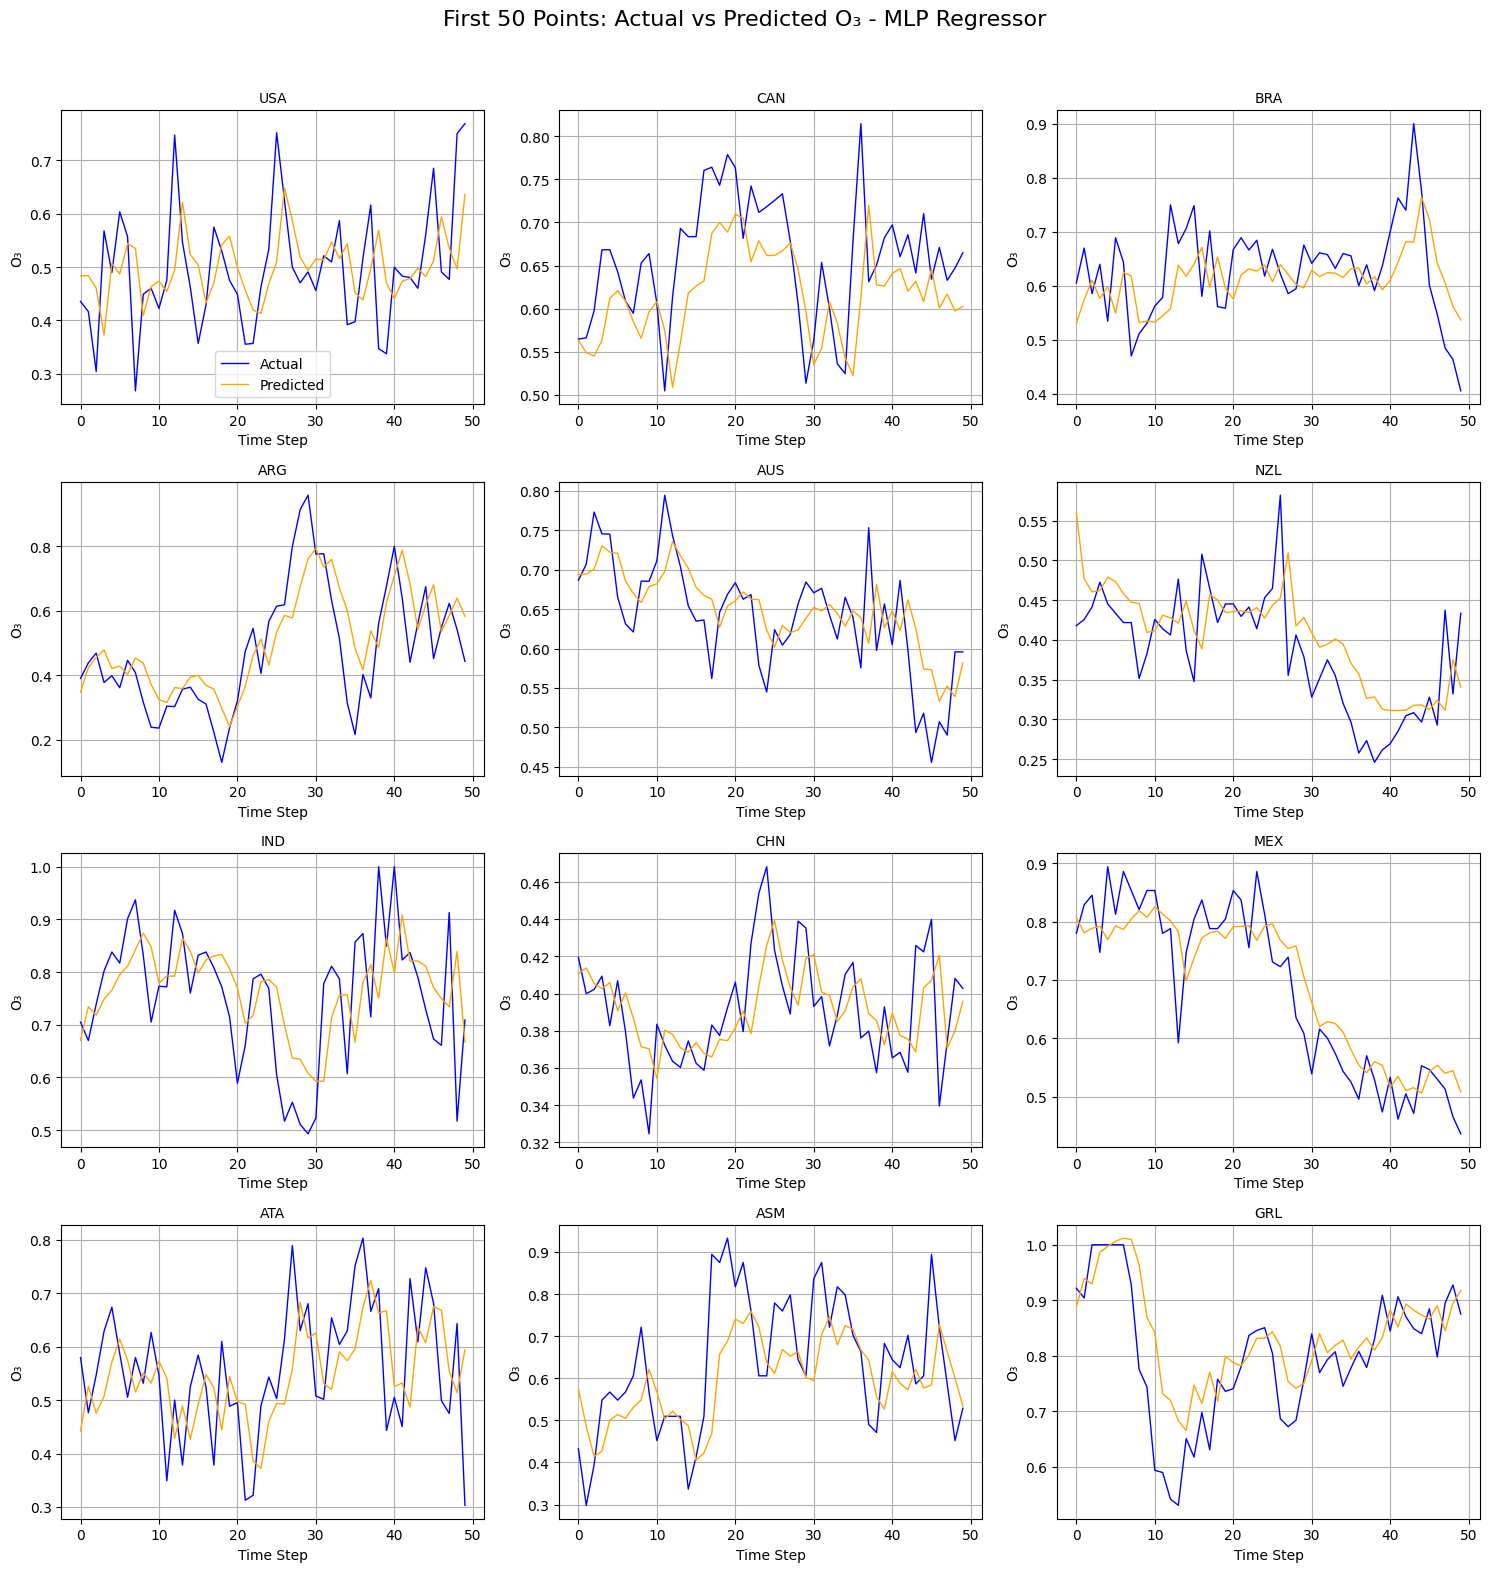

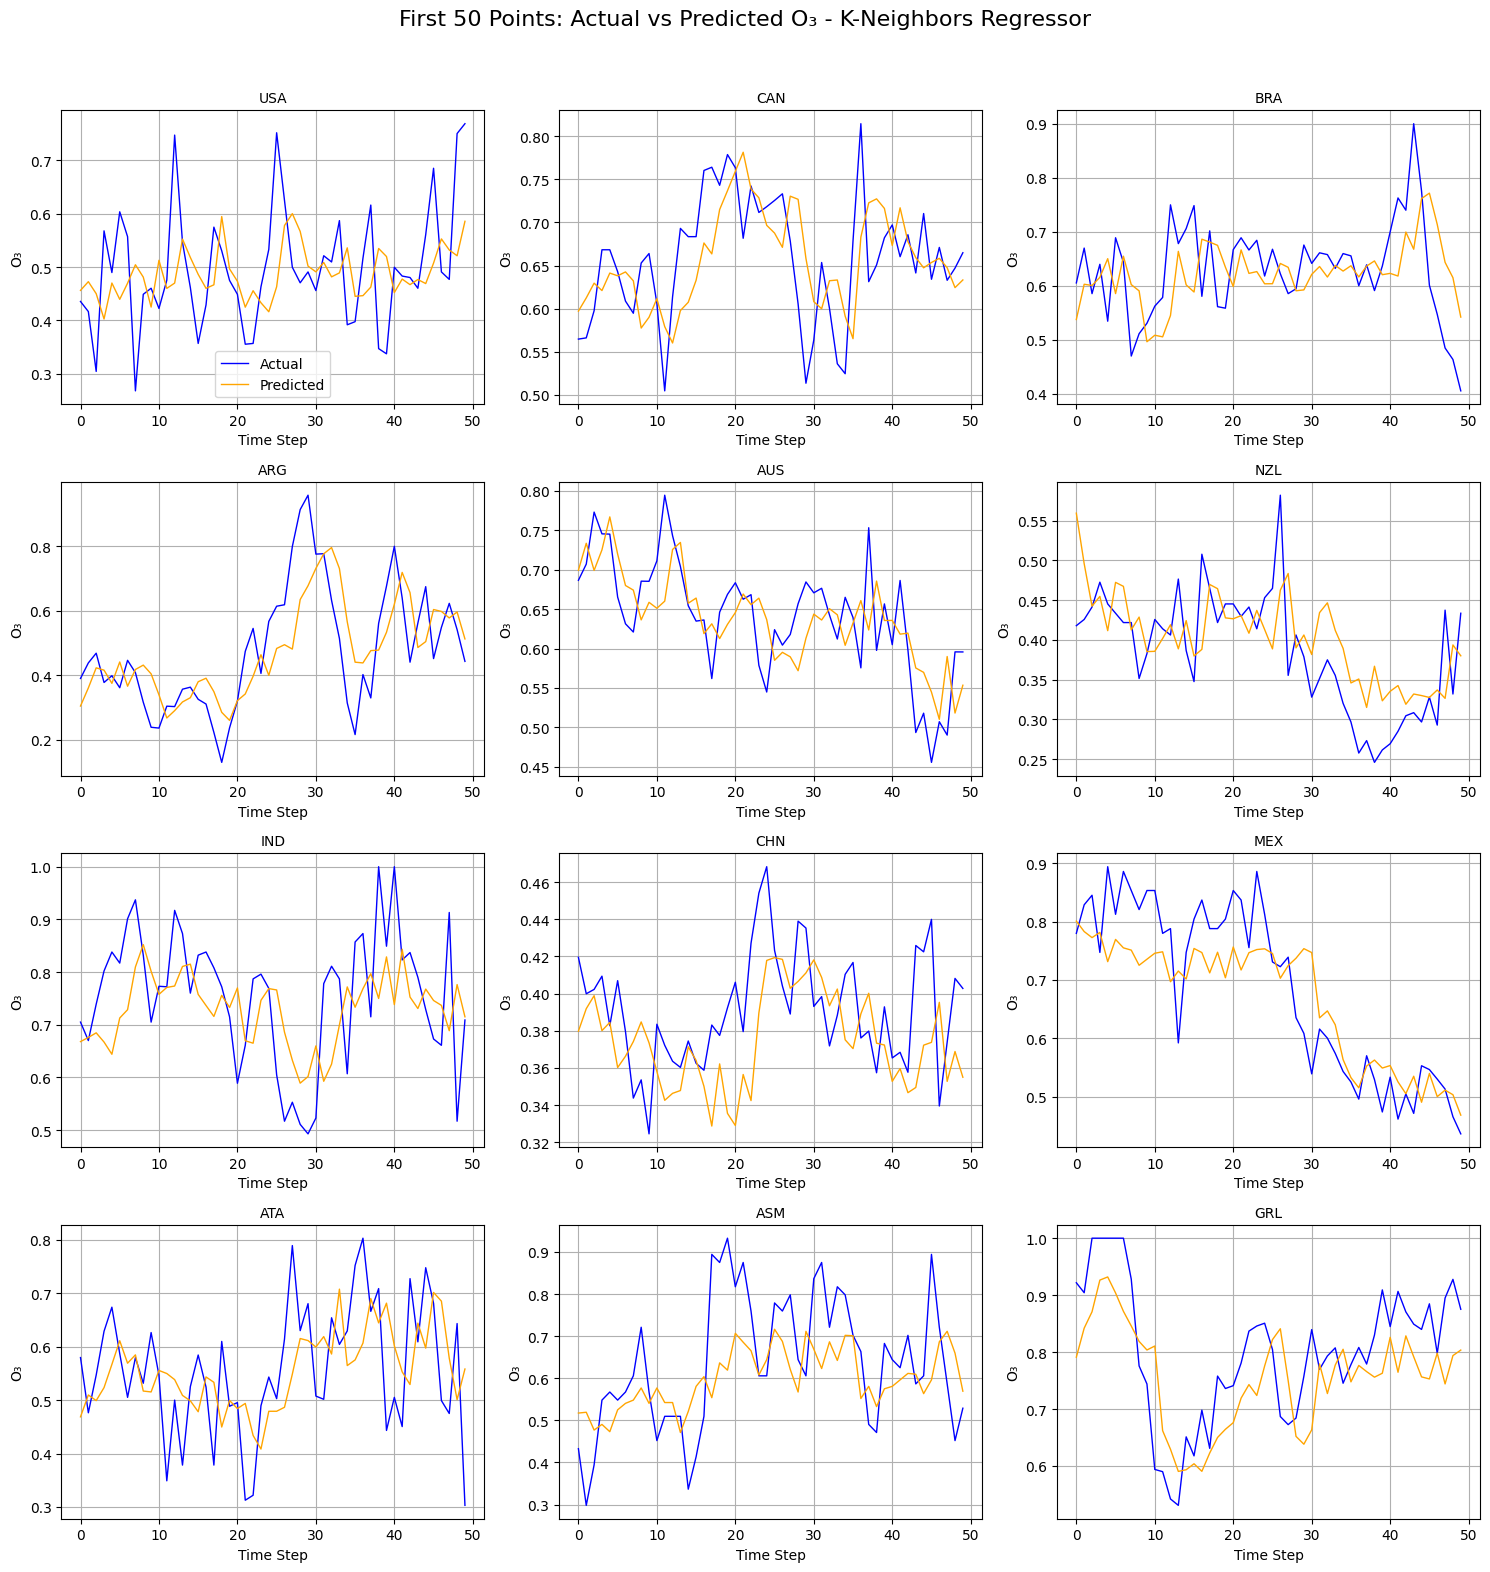

In [22]:
import math

def plot_first_50_points_per_model():
    for model_name in model_classes.keys():
        countries = list(all_results[model_name].keys())
        n_countries = len(countries)
        cols = 3
        rows = math.ceil(n_countries / cols)

        plt.figure(figsize=(cols * 5, rows * 4))
        plt.suptitle(f'First 50 Points: Actual vs Predicted O₃ - {model_name}', fontsize=16)

        for i, country in enumerate(countries, 1):
            result = all_results[model_name][country]
            actuals = result['Actuals'][:50]
            predictions = result['Predictions'][:50]

            plt.subplot(rows, cols, i)
            plt.plot(actuals, label='Actual', color='blue', linewidth=1)
            plt.plot(predictions, label='Predicted', color='orange', linewidth=1)
            plt.title(country, fontsize=10)
            plt.xlabel("Time Step")
            plt.ylabel("O₃")
            plt.grid(True)
            if i == 1:
                plt.legend()

        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()

# Call this after training and populating all_results
plot_first_50_points_per_model()


**Average Model Performance**

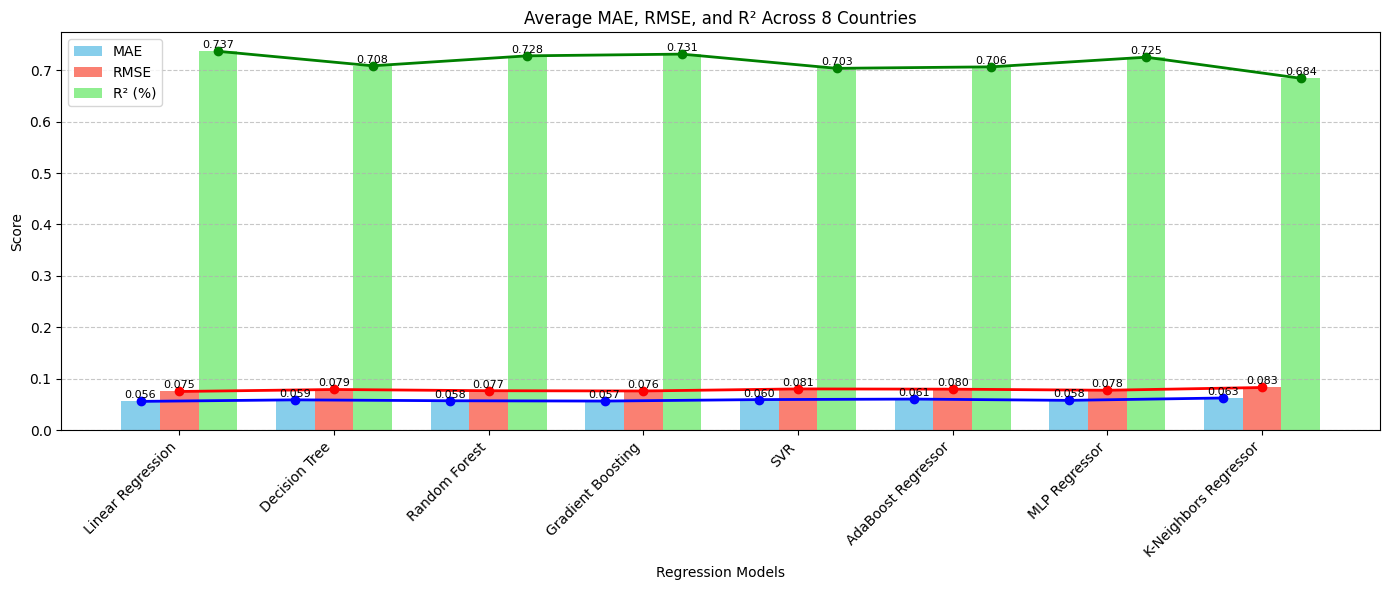

In [23]:
import matplotlib.pyplot as plt
import numpy as np

# Raw evaluation metrics
model_metrics = {
    "Linear Regression": {
        "MAE": [0.055, 0.040, 0.058, 0.072, 0.091, 0.048, 0.042, 0.044],
        "RMSE": [0.077, 0.056, 0.078, 0.094, 0.118, 0.069, 0.054, 0.058],
        "R2": [0.7827, 0.8824, 0.7706, 0.7028, 0.4782, 0.8326, 0.8518, 0.5917],
    },
    "Decision Tree": {
        "MAE": [0.059, 0.041, 0.060, 0.075, 0.094, 0.051, 0.047, 0.047],
        "RMSE": [0.081, 0.058, 0.080, 0.098, 0.122, 0.072, 0.062, 0.062],
        "R2": [0.7585, 0.8755, 0.7595, 0.6792, 0.4371, 0.8185, 0.8090, 0.5299],
    },
    "Random Forest": {
        "MAE": [0.057, 0.040, 0.059, 0.073, 0.092, 0.050, 0.045, 0.044],
        "RMSE": [0.080, 0.056, 0.078, 0.095, 0.120, 0.071, 0.057, 0.059],
        "R2": [0.7699, 0.8812, 0.7688, 0.6984, 0.4628, 0.8243, 0.8342, 0.5825],
    },
    "Gradient Boosting": {
        "MAE": [0.057, 0.040, 0.059, 0.072, 0.091, 0.049, 0.044, 0.043],
        "RMSE": [0.079, 0.056, 0.078, 0.095, 0.118, 0.071, 0.057, 0.058],
        "R2": [0.7751, 0.8820, 0.7684, 0.6998, 0.4723, 0.8246, 0.8385, 0.5881],
    },
    "SVR": {
        "MAE": [0.059, 0.041, 0.062, 0.075, 0.096, 0.054, 0.046, 0.045],
        "RMSE": [0.085, 0.059, 0.082, 0.098, 0.124, 0.076, 0.059, 0.061],
        "R2": [0.7393, 0.8690, 0.7447, 0.6804, 0.4249, 0.7986, 0.8246, 0.5462],
    },
    "AdaBoost Regressor": {
        "MAE": [0.064, 0.043, 0.062, 0.075, 0.095, 0.051, 0.048, 0.048],
        "RMSE": [0.086, 0.059, 0.081, 0.097, 0.122, 0.072, 0.061, 0.062],
        "R2": [0.7329, 0.8714, 0.7484, 0.6848, 0.4417, 0.8214, 0.8119, 0.5386],
    },
    "MLP Regressor": {
        "MAE": [0.055, 0.040, 0.060, 0.074, 0.090, 0.062, 0.043, 0.042],
        "RMSE": [0.077, 0.057, 0.079, 0.097, 0.118, 0.082, 0.055, 0.058],
        "R2": [0.7828, 0.8804, 0.7606, 0.6867, 0.4794, 0.7657, 0.8473, 0.5980],
    },
    "K-Neighbors Regressor": {
        "MAE": [0.060, 0.044, 0.066, 0.081, 0.099, 0.057, 0.049, 0.047],
        "RMSE": [0.082, 0.061, 0.085, 0.106, 0.127, 0.079, 0.063, 0.063],
        "R2": [0.7560, 0.8612, 0.7225, 0.6276, 0.3953, 0.7835, 0.8029, 0.5243],
    },
}


# Calculate average values
model_names = []
avg_mae = []
avg_rmse = []
avg_r2 = []

for model, metrics in model_metrics.items():
    model_names.append(model)
    avg_mae.append(np.mean(metrics['MAE']))
    avg_rmse.append(np.mean(metrics['RMSE']))
    avg_r2.append(np.mean(metrics['R2']))  # Already in %

# Plot
x = np.arange(len(model_names))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 6))
bar1 = ax.bar(x - width, avg_mae, width, label='MAE', color='skyblue')
bar2 = ax.bar(x, avg_rmse, width, label='RMSE', color='salmon')
bar3 = ax.bar(x + width, avg_r2, width, label='R² (%)', color='lightgreen')

# Connecting lines
ax.plot(x - width, avg_mae, color='blue', marker='o', linewidth=2)
ax.plot(x, avg_rmse, color='red', marker='o', linewidth=2)
ax.plot(x + width, avg_r2, color='green', marker='o', linewidth=2)

# Labels
ax.set_xlabel('Regression Models')
ax.set_ylabel('Score')
ax.set_title('Average MAE, RMSE, and R² Across 8 Countries')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=45, ha='right')
ax.legend()
ax.grid(True, axis='y', linestyle='--', alpha=0.7)

# Bar value labels
for bars in [bar1, bar2, bar3]:
    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, yval + 0.002, f"{yval:.3f}",
                ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()


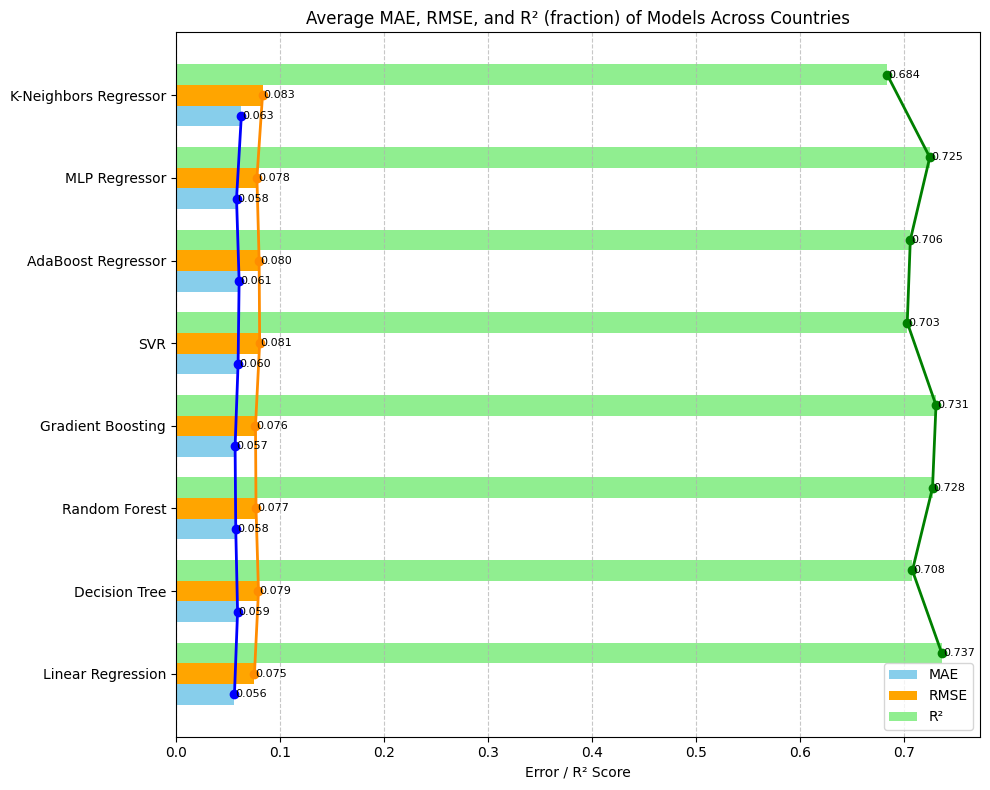

In [24]:
import matplotlib.pyplot as plt
import numpy as np

# Raw metrics
metrics = {
    "Linear Regression": {
        "MAE": [0.055, 0.040, 0.058, 0.072, 0.091, 0.048, 0.042, 0.044],
        "RMSE": [0.077, 0.056, 0.078, 0.094, 0.118, 0.069, 0.054, 0.058],
        "R2": [0.7827, 0.8824, 0.7706, 0.7028, 0.4782, 0.8326, 0.8518, 0.5917],
    },
    "Decision Tree": {
        "MAE": [0.059, 0.041, 0.060, 0.075, 0.094, 0.051, 0.047, 0.047],
        "RMSE": [0.081, 0.058, 0.080, 0.098, 0.122, 0.072, 0.062, 0.062],
        "R2": [0.7585, 0.8755, 0.7595, 0.6792, 0.4371, 0.8185, 0.8090, 0.5299],
    },
    "Random Forest": {
        "MAE": [0.057, 0.040, 0.059, 0.073, 0.092, 0.050, 0.045, 0.044],
        "RMSE": [0.080, 0.056, 0.078, 0.095, 0.120, 0.071, 0.057, 0.059],
        "R2": [0.7699, 0.8812, 0.7688, 0.6984, 0.4628, 0.8243, 0.8342, 0.5825],
    },
    "Gradient Boosting": {
        "MAE": [0.057, 0.040, 0.059, 0.072, 0.091, 0.049, 0.044, 0.043],
        "RMSE": [0.079, 0.056, 0.078, 0.095, 0.118, 0.071, 0.057, 0.058],
        "R2": [0.7751, 0.8820, 0.7684, 0.6998, 0.4723, 0.8246, 0.8385, 0.5881],
    },
    "SVR": {
        "MAE": [0.059, 0.041, 0.062, 0.075, 0.096, 0.054, 0.046, 0.045],
        "RMSE": [0.085, 0.059, 0.082, 0.098, 0.124, 0.076, 0.059, 0.061],
        "R2": [0.7393, 0.8690, 0.7447, 0.6804, 0.4249, 0.7986, 0.8246, 0.5462],
    },
    "AdaBoost Regressor": {
        "MAE": [0.064, 0.043, 0.062, 0.075, 0.095, 0.051, 0.048, 0.048],
        "RMSE": [0.086, 0.059, 0.081, 0.097, 0.122, 0.072, 0.061, 0.062],
        "R2": [0.7329, 0.8714, 0.7484, 0.6848, 0.4417, 0.8214, 0.8119, 0.5386],
    },
    "MLP Regressor": {
        "MAE": [0.055, 0.040, 0.060, 0.074, 0.090, 0.062, 0.043, 0.042],
        "RMSE": [0.077, 0.057, 0.079, 0.097, 0.118, 0.082, 0.055, 0.058],
        "R2": [0.7828, 0.8804, 0.7606, 0.6867, 0.4794, 0.7657, 0.8473, 0.5980],
    },
    "K-Neighbors Regressor": {
        "MAE": [0.060, 0.044, 0.066, 0.081, 0.099, 0.057, 0.049, 0.047],
        "RMSE": [0.082, 0.061, 0.085, 0.106, 0.127, 0.079, 0.063, 0.063],
        "R2": [0.7560, 0.8612, 0.7225, 0.6276, 0.3953, 0.7835, 0.8029, 0.5243],
    },
}

model_names = list(metrics.keys())
avg_mae = [np.mean(m["MAE"]) for m in metrics.values()]
avg_rmse = [np.mean(m["RMSE"]) for m in metrics.values()]
avg_r2 = [np.mean(m["R2"]) for m in metrics.values()]

# Bar settings
y = np.arange(len(model_names))
bar_height = 0.25

fig, ax = plt.subplots(figsize=(10, 8))

# Bar plots
mae_bars = ax.barh(y - bar_height, avg_mae, height=bar_height, label="MAE", color='skyblue')
rmse_bars = ax.barh(y, avg_rmse, height=bar_height, label="RMSE", color='orange')
r2_bars = ax.barh(y + bar_height, avg_r2, height=bar_height, label="R²", color='lightgreen')

# Connecting lines
ax.plot(avg_mae, y - bar_height, color='blue', marker='o', linewidth=2)
ax.plot(avg_rmse, y, color='darkorange', marker='o', linewidth=2)
ax.plot(avg_r2, y + bar_height, color='green', marker='o', linewidth=2)

# Value labels
for i in range(len(model_names)):
    ax.text(avg_mae[i] + 0.001, y[i] - bar_height, f"{avg_mae[i]:.3f}", va='center', fontsize=8)
    ax.text(avg_rmse[i] + 0.001, y[i], f"{avg_rmse[i]:.3f}", va='center', fontsize=8)
    ax.text(avg_r2[i] + 0.001, y[i] + bar_height, f"{avg_r2[i]:.3f}", va='center', fontsize=8)

# Final touches
ax.set_yticks(y)
ax.set_yticklabels(model_names)
ax.set_xlabel("Error / R² Score")
ax.set_title("Average MAE, RMSE, and R² (fraction) of Models Across Countries")
ax.legend()
ax.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


In [29]:
import pandas as pd

# Prepare evaluation metrics DataFrame
metrics_records = []
for model in all_results:
    for country, res in all_results[model].items():
        metrics_records.append({
            'Model': model,
            'Country': country,
            'RMSE': res['RMSE'],
            'MAE': res['MAE'],
            'R2': res['R2']
        })
metrics_df = pd.DataFrame(metrics_records)

# Save evaluation metrics to a spreadsheet
metrics_df.to_excel('evaluation_metrics.xlsx', index=False)

# Prepare actual vs predicted DataFrame
rows = []
for model in all_results:
    for country, res in all_results[model].items():
        actuals = res['Actuals']
        preds = res['Predictions']
        for idx, (a, p) in enumerate(zip(actuals, preds)):
            rows.append({
                'Model': model,
                'Country': country,
                'Index': idx,
                'Actual': a,
                'Predicted': p
            })
actual_pred_df = pd.DataFrame(rows)

# Save actual vs predicted values to a separate spreadsheet
actual_pred_df.to_excel('actual_vs_predicted.xlsx', index=False)


<h1>Generic Combined Country Model Check</h1>

In [219]:
df=pd.concat([df1, df2, df3, df4, df5, df6, df7, df8], ignore_index=True)
df['daily_date'] = pd.to_datetime(df['daily_date'], format='%Y-%m-%d')
df.head()

,x,y,identifier,file_path,dataset_id,station_id,station_name,station_gaw_id,station_gaw_url,contributor_name,...,daily_utc_end,daily_utc_mean,daily_nobs,daily_mmu,daily_columnso2,monthly_date,monthly_columno3,monthly_stdevo3,monthly_npts,url
0,-58.480,-34.580,Dobson:Beck:70:TotalOzone_1.0:091:SMNA:WOUDC:2...,/apps/data/wdr-ingest/Archive-NewFormat/TotalO...,TotalOzone_1.0,91,Buenos Aires Observatorio,BSO,https://gawsis.meteoswiss.ch/GAWSIS/index.html...,National Meteorological Service of Argentina,...,15.0,NaN,6.0,1.800,NaN,2025-04-30T00:00:00Z,277.2,13.9,29.0,https://woudc.org/archive/Archive-NewFormat/To...
1,-68.310,-54.850,Dobson:Beck:131:TotalOzone_1.0:339:SMNA:WOUDC:...,/apps/data/wdr-ingest/Archive-NewFormat/TotalO...,TotalOzone_1.0,339,Ushuaia,USH,https://gawsis.meteoswiss.ch/GAWSIS/index.html...,National Meteorological Service of Argentina,...,17.5,17.5,1.0,2.976,NaN,2025-04-30T00:00:00Z,277.0,27.7,30.0,https://woudc.org/archive/Archive-NewFormat/To...
2,-67.500,-45.783,Dobson:Beck:133:TotalOzone_1.0:342:SMNA:WOUDC:...,/apps/data/wdr-ingest/Archive-NewFormat/TotalO...,TotalOzone_1.0,342,Comodoro Rivadavia Aero,CMR,https://gawsis.meteoswiss.ch/GAWSIS/index.html...,National Meteorological Service of Argentina,...,16.0,NaN,8.0,2.300,NaN,2025-04-30T00:00:00Z,263.4,21.7,28.0,https://woudc.org/archive/Archive-NewFormat/To...
3,-65.438,-22.111,Dobson:Beck:97:TotalOzone_1.0:513:SMNA:WOUDC:2...,/apps/data/wdr-ingest/Archive-NewFormat/TotalO...,TotalOzone_1.0,513,La Quiaca,LQO,https://gawsis.meteoswiss.ch/GAWSIS/index.html...,National Meteorological Service of Argentina,...,15.0,NaN,3.0,1.500,NaN,2025-04-30T00:00:00Z,254.1,3.5,25.0,https://woudc.org/archive/Archive-NewFormat/To...
4,-58.480,-34.580,Dobson:Beck:70:TotalOzone_1.0:091:SMNA:WOUDC:2...,/apps/data/wdr-ingest/Archive-NewFormat/TotalO...,TotalOzone_1.0,91,Buenos Aires Observatorio,BSO,https://gawsis.meteoswiss.ch/GAWSIS/index.html...,National Meteorological Service of Argentina,...,15.0,NaN,6.0,1.700,NaN,2025-04-30T00:00:00Z,277.2,13.9,29.0,https://woudc.org/archive/Archive-NewFormat/To...


**Pre-Processing**

*Checking Null Values*

In [220]:
#finding missing value
print('Missing Value:')
print(df.isnull().sum())
print('***'*10)
#finding percantage of missing value
print('Percentage of Missing Value:')
print(df.isnull().sum()/df.shape[0]*100)
print('***'*10)
#finding duplicates
print('Duplicates:')
print(df.duplicated().sum())
print('***'*10)
#idenfying garbage value
print('Garbage Value:')
for i in df.select_dtypes(include='object').columns: #cz garbage are in object type value
   print(df[i].value_counts())
   print('***'*10)
# no garbage value as it would show in the last and show the character and the count also


Missing Value:
x                         0
y                         0
identifier                0
file_path                 0
dataset_id                0
station_id                0
station_name              0
station_gaw_id         1698
station_gaw_url           0
contributor_name          0
contributor_id            0
contributor_url       20833
country_id                0
country_name_en           0
country_name_fr           0
gaw_id               437135
instrument_name           0
instrument_model          0
instrument_serial         0
observation_date          0
daily_date                0
daily_wlcode           6829
daily_obscode             1
daily_columno3            0
daily_stdevo3        223703
daily_utc_begin      277790
daily_utc_end        277760
daily_utc_mean        39540
daily_nobs           224168
daily_mmu            252080
daily_columnso2      281795
monthly_date           8832
monthly_columno3       8832
monthly_stdevo3        8837
monthly_npts           8859
url  

**Droping Other Unnecessary Columns**

In [221]:
columns = [
    'x',
    'y',
    'identifier',
    'file_path',
    'dataset_id',
    'station_id',
    'station_name',
    'station_gaw_id',
    'station_gaw_url',
    'contributor_name',
    'contributor_id',
    'contributor_url',
    'country_id',
    'country_name_en',
    'country_name_fr',
    'gaw_id',
    'instrument_name',
    'instrument_model',
    'instrument_serial',
    'observation_date',
    'daily_wlcode',
    'daily_obscode',
    'daily_stdevo3',
    'daily_utc_begin',
    'daily_utc_end',
    'daily_utc_mean',
    'daily_nobs',
    'daily_mmu',
    'daily_columnso2',
    'monthly_date',
    'monthly_columno3',
    'monthly_stdevo3',
    'monthly_npts',
    'url',
    # 'Year',
    # 'period',
]
df.drop(columns=columns, inplace=True)

df.head()

,daily_date,daily_columno3
0,2025-04-30 00:00:00+00:00,264.0
1,2025-04-30 00:00:00+00:00,327.0
2,2025-04-30 00:00:00+00:00,256.0
3,2025-04-30 00:00:00+00:00,255.0
4,2025-04-29 00:00:00+00:00,265.0


**Grouping Values with same date-time**

In [222]:
#finding missing value
print('Missing Value:')
print(df.isnull().sum())
print('***'*10)
#finding percantage of missing value
print('Percentage of Missing Value:')
print(df.isnull().sum()/df.shape[0]*100)
print('***'*10)
#finding duplicates
print('Duplicates:')
print(df.duplicated().sum())
print('***'*10)
#idenfying garbage value
print('Garbage Value:')
for i in df.select_dtypes(include='object').columns: #cz garbage are in object type value
   print(df[i].value_counts())
   print('***'*10)
# no garbage value as it would show in the last and show the character and the count also


Missing Value:
daily_date        0
daily_columno3    0
dtype: int64
******************************
Percentage of Missing Value:
daily_date        0.0
daily_columno3    0.0
dtype: float64
******************************
Duplicates:
10879
******************************
Garbage Value:


In [223]:
df = df.groupby('daily_date').mean(numeric_only=True).reset_index()
df = df.sort_values('daily_date', ascending=True).reset_index(drop=True)
df.dropna(subset=['daily_columno3'], inplace=True)

df.head()

,daily_date,daily_columno3
0,1957-07-01 00:00:00+00:00,337.766667
1,1957-07-02 00:00:00+00:00,303.966667
2,1957-07-03 00:00:00+00:00,322.500000
3,1957-07-04 00:00:00+00:00,322.500000
4,1957-07-05 00:00:00+00:00,317.966667


In [224]:
print(F"Shape after dropping NaN values: {df.shape}")

Shape after dropping NaN values: (24745, 2)


**Checking For Outliers**

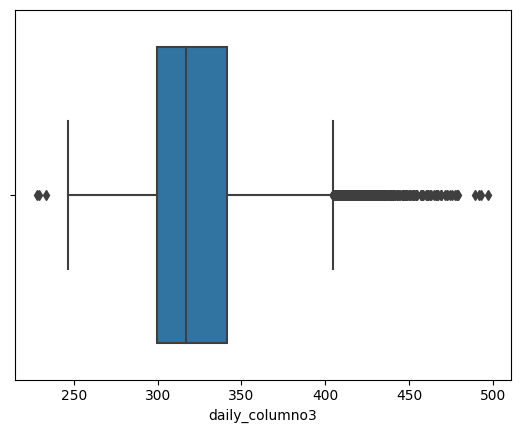

In [225]:
for i in ["daily_columno3"]:
  sns.boxplot(data=df,x=i)
  plt.show()

**Calculating Wiskers to treat outliers**

In [226]:
#Outlier treatment
def wisker(col):
  q1,q3=np.percentile(col,[25,75])
  iqr=q3-q1
  lower_bound=q1-(1.5*iqr)
  upper_bound=q3+(1.5*iqr)
  return lower_bound,upper_bound
df.columns

Index(['daily_date', 'daily_columno3'], dtype='object')

**Treating Outliers**

In [227]:
for i in ["daily_columno3"]:
  lw,uk=wisker(df[i])
  df[i]=np.where(df[i]>uk,uk,df[i])
  df[i]=np.where(df[i]<lw,lw,df[i])

**Checking If outliers Remains**

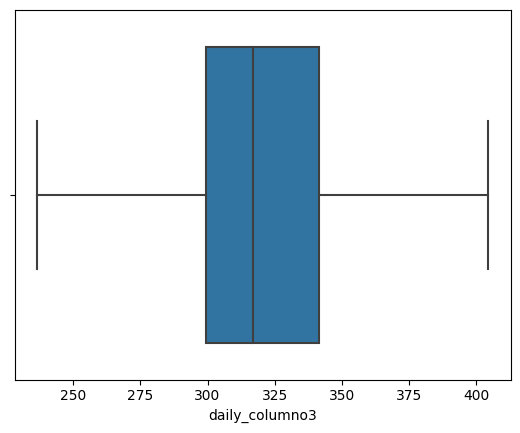

In [228]:
for i in ["daily_columno3"]:
  sns.boxplot(data=df,x=i)
  plt.show()

**Creating Lag features**

In [229]:
df['rolling_avg'] = df['daily_columno3'].shift(1).rolling(window=10).mean().bfill()
df['rolling_std'] = df['daily_columno3'].shift(1).rolling(window=10).std().bfill()
df['ewm_avg'] = df['daily_columno3'].shift(1).ewm(span=10).mean().bfill()
df['ewm_std'] = df['daily_columno3'].shift(1).ewm(span=10).std().bfill()
for i in range(1, 16):
  df[f'lag{i}'] = df['daily_columno3'].shift(i)

df.dropna(inplace=True)
print(df.shape)
df.head()

(24730, 21)


,daily_date,daily_columno3,rolling_avg,rolling_std,ewm_avg,ewm_std,lag1,lag2,lag3,lag4,...,lag6,lag7,lag8,lag9,lag10,lag11,lag12,lag13,lag14,lag15
15,1957-07-16 00:00:00+00:00,335.94,330.374167,5.969687,328.764897,6.688511,329.88,322.45,330.525,327.400,...,335.180,326.066667,325.733333,339.800000,327.066667,317.966667,322.500000,322.500000,303.966667,337.766667
16,1957-07-17 00:00:00+00:00,328.16,331.261500,6.081848,330.124281,6.711755,335.94,329.88,322.450,330.525,...,339.640,335.180000,326.066667,325.733333,339.800000,327.066667,317.966667,322.500000,322.500000,303.966667
17,1957-07-18 00:00:00+00:00,318.60,330.097500,5.334002,329.754953,6.096926,328.16,335.94,329.880,322.450,...,327.400,339.640000,335.180000,326.066667,325.733333,339.800000,327.066667,317.966667,322.500000,322.500000
18,1957-07-19 00:00:00+00:00,315.88,329.384167,6.360663,327.670509,7.163891,318.60,328.16,335.940,329.880,...,330.525,327.400000,339.640000,335.180000,326.066667,325.733333,339.800000,327.066667,317.966667,322.500000
19,1957-07-20 00:00:00+00:00,310.10,328.365500,7.638370,325.478361,8.076394,315.88,318.60,328.160,335.940,...,322.450,330.525000,327.400000,339.640000,335.180000,326.066667,325.733333,339.800000,327.066667,317.966667


**Spliting and scalling data**

In [230]:
lag_features = [f'lag{i}' for i in range(1, 16)]
lag_features.append('rolling_avg')
lag_features.append('rolling_std')
lag_features.append('ewm_avg')
lag_features.append('ewm_std')
X= df[lag_features]
y = df['daily_columno3']

minmax_x = MinMaxScaler()
minmax_y = MinMaxScaler()
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
# Scale the features
X_train= minmax_x.fit_transform(X_train)
X_test= minmax_x.transform(X_test)
# Scale the target variable
y_train= minmax_y.fit_transform(y_train.values.reshape(-1, 1)).flatten()
y_test= minmax_y.transform(y_test.values.reshape(-1, 1)).flatten()

**Training Models**

In [231]:


# STEP 3: Define models
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'Support Vector Regressor': SVR(),
    'AdaBoost Regressor': AdaBoostRegressor(n_estimators=50, random_state=42),
    'MLP Regressor': MLPRegressor(hidden_layer_sizes=(50,), max_iter=500, random_state=42),
    'K-Neighbors Regressor': KNeighborsRegressor(n_neighbors=3)
}

# STEP 4: Train, Predict, and Evaluate
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    
    results[name] = {
        'Model': model,
        'Predictions': preds,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2
    }

# STEP 5: Print evaluation metrics
print("Model Evaluation Metrics:\n")
for name, res in results.items():
    print(f"----- {name} -----")
    print(f"RMSE: {res['RMSE']:.3f}")
    print(f"MAE : {res['MAE']:.3f}")
    print(f"R2  : {(res['R2']*100):.2f} %\n")

# STEP 6: Plot actual vs predicted

Model Evaluation Metrics:

----- Linear Regression -----
RMSE: 0.056
MAE : 0.041
R2  : 87.36 %

----- Decision Tree -----
RMSE: 0.079
MAE : 0.059
R2  : 74.42 %

----- Random Forest -----
RMSE: 0.057
MAE : 0.042
R2  : 86.73 %

----- Gradient Boosting -----
RMSE: 0.056
MAE : 0.041
R2  : 87.15 %

----- Support Vector Regressor -----
RMSE: 0.058
MAE : 0.043
R2  : 86.15 %

----- AdaBoost Regressor -----
RMSE: 0.065
MAE : 0.050
R2  : 82.88 %

----- MLP Regressor -----
RMSE: 0.056
MAE : 0.041
R2  : 87.16 %

----- K-Neighbors Regressor -----
RMSE: 0.066
MAE : 0.049
R2  : 82.22 %



**HyperParameter Tuning**

In [232]:

param_spaces = {
    'Linear Regression': {},
    'Decision Tree': {
        'max_depth': ('int', 3, 10),
        'min_samples_split': ('int', 2, 10),
    },
    'Random Forest': {
        'n_estimators': ('int', 50, 200),
        'max_depth': ('int', 3, 10),
    },
    'Gradient Boosting': {
        'n_estimators': ('int', 50, 200),
        'learning_rate': ('float', 0.01, 0.3),
        'max_depth': ('int', 3, 7),
    },
    'SVR': {
        'C': ('float', 0.1, 10),
        'epsilon': ('float', 0.01, 1.0),
    },
    'AdaBoost Regressor': {
        'n_estimators': ('int', 50, 150),
        'learning_rate': ('float', 0.01, 1.0),
    },
    'MLP Regressor': {
        'hidden_layer_sizes': ('cat', [(50,), (100,), (50, 50)]),
        'alpha': ('float', 0.0001, 0.01),
        'learning_rate_init': ('float', 0.001, 0.05),
    },
    'K-Neighbors Regressor': {
        'n_neighbors': ('int', 2, 10),
    }
}

# ----------- STEP 4: Models Dictionary ----------- #
model_classes = {
    'Linear Regression': LinearRegression,
    'Decision Tree': DecisionTreeRegressor,
    'Random Forest': RandomForestRegressor,
    'Gradient Boosting': GradientBoostingRegressor,
    'SVR': SVR,
    'AdaBoost Regressor': AdaBoostRegressor,
    'MLP Regressor': MLPRegressor,
    'K-Neighbors Regressor': KNeighborsRegressor,
}

# ----------- STEP 5: Suggestion Utility ----------- #
def suggest(trial, name, dist):
    if isinstance(dist, tuple) and dist[0] == 'int':
        return trial.suggest_int(name, *dist[1:])
    elif isinstance(dist, tuple) and dist[0] == 'float':
        return trial.suggest_float(name, *dist[1:])
    elif isinstance(dist, tuple) and dist[0] == 'cat':
        return trial.suggest_categorical(name, dist[1])
    else:
        raise ValueError(f"Unsupported distribution type for {name}: {dist}")

# ----------- STEP 6: Model Tuning Function ----------- #
def tune_model(name, model_class, param_space, n_trials=10):
    if not param_space:
        return model_class()

    def objective(trial):
        params = {key: suggest(trial, key, dist) for key, dist in param_space.items()}
        model = model_class(**params)
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        rmse = mean_squared_error(y_test, preds)
        return rmse

    study = optuna.create_study(direction='minimize', sampler=TPESampler(seed=42))
    study.optimize(objective, n_trials=n_trials)
    print(f"{name} Best Params: {study.best_params}")
    return model_class(**study.best_params)

# ----------- STEP 7: Tuning and Evaluation ----------- #
results = {}
best_models = {}

for name in model_classes:
    print(f"\nTuning {name}...")
    model = tune_model(name, model_classes[name], param_spaces.get(name, {}), n_trials=20)
    model.fit(X_train, y_train)
    best_models[name] = model

    preds = model.predict(X_test)
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)

    results[name] = {
        'Predictions': preds,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2
    }

# ----------- STEP 8: Print Metrics ----------- #
print("\nModel Evaluation Metrics:\n")
for name, res in results.items():
    print(f"----- {name} -----")
    print(f"RMSE: {res['RMSE']:.3f}")
    print(f"MAE : {res['MAE']:.3f}")
    print(f"R2  : {(res['R2'] * 100):.2f} %\n")



[I 2025-06-12 22:37:07,947] A new study created in memory with name: no-name-0a5a8d65-6ac2-40b0-bf0b-6fb9e316c15e



Tuning Linear Regression...

Tuning Decision Tree...


[I 2025-06-12 22:37:08,115] Trial 0 finished with value: 0.0033573491675819543 and parameters: {'max_depth': 5, 'min_samples_split': 10}. Best is trial 0 with value: 0.0033573491675819543.
[I 2025-06-12 22:37:08,325] Trial 1 finished with value: 0.003623448406503451 and parameters: {'max_depth': 8, 'min_samples_split': 7}. Best is trial 0 with value: 0.0033573491675819543.
[I 2025-06-12 22:37:08,435] Trial 2 finished with value: 0.0035562036519735277 and parameters: {'max_depth': 4, 'min_samples_split': 3}. Best is trial 0 with value: 0.0033573491675819543.
[I 2025-06-12 22:37:08,506] Trial 3 finished with value: 0.00409880312648952 and parameters: {'max_depth': 3, 'min_samples_split': 9}. Best is trial 0 with value: 0.0033573491675819543.
[I 2025-06-12 22:37:08,688] Trial 4 finished with value: 0.0034479251692344872 and parameters: {'max_depth': 7, 'min_samples_split': 8}. Best is trial 0 with value: 0.0033573491675819543.
[I 2025-06-12 22:37:08,767] Trial 5 finished with value: 0.004

Decision Tree Best Params: {'max_depth': 6, 'min_samples_split': 2}

Tuning Random Forest...


[I 2025-06-12 22:37:26,904] Trial 0 finished with value: 0.0031429261449222087 and parameters: {'n_estimators': 106, 'max_depth': 10}. Best is trial 0 with value: 0.0031429261449222087.
[I 2025-06-12 22:37:45,692] Trial 1 finished with value: 0.003096204821694166 and parameters: {'n_estimators': 160, 'max_depth': 7}. Best is trial 1 with value: 0.003096204821694166.
[I 2025-06-12 22:37:50,572] Trial 2 finished with value: 0.003309189784720651 and parameters: {'n_estimators': 73, 'max_depth': 4}. Best is trial 1 with value: 0.003096204821694166.
[I 2025-06-12 22:37:58,114] Trial 3 finished with value: 0.003118683235033053 and parameters: {'n_estimators': 58, 'max_depth': 9}. Best is trial 1 with value: 0.003096204821694166.
[I 2025-06-12 22:38:14,600] Trial 4 finished with value: 0.0031159398020891996 and parameters: {'n_estimators': 140, 'max_depth': 8}. Best is trial 1 with value: 0.003096204821694166.
[I 2025-06-12 22:38:22,127] Trial 5 finished with value: 0.003157428576557875 and p

...

MLP Regressor Best Params: {'hidden_layer_sizes': (100,), 'alpha': 0.001794918594928324, 'learning_rate_init': 0.02864787614752198}


[I 2025-06-12 22:53:40,744] A new study created in memory with name: no-name-20eceb3e-46a8-4cfd-8a55-f8bc5c5b7742



Tuning K-Neighbors Regressor...


[I 2025-06-12 22:53:42,294] Trial 0 finished with value: 0.00394734511697004 and parameters: {'n_neighbors': 5}. Best is trial 0 with value: 0.00394734511697004.
[I 2025-06-12 22:53:43,707] Trial 1 finished with value: 0.0037016153363662475 and parameters: {'n_neighbors': 10}. Best is trial 1 with value: 0.0037016153363662475.
[I 2025-06-12 22:53:45,090] Trial 2 finished with value: 0.0037726162065070384 and parameters: {'n_neighbors': 8}. Best is trial 1 with value: 0.0037016153363662475.
[I 2025-06-12 22:53:46,554] Trial 3 finished with value: 0.0038140498921089955 and parameters: {'n_neighbors': 7}. Best is trial 1 with value: 0.0037016153363662475.
[I 2025-06-12 22:53:47,935] Trial 4 finished with value: 0.004337274914625838 and parameters: {'n_neighbors': 3}. Best is trial 1 with value: 0.0037016153363662475.
[I 2025-06-12 22:53:49,335] Trial 5 finished with value: 0.004337274914625838 and parameters: {'n_neighbors': 3}. Best is trial 1 with value: 0.0037016153363662475.
[I 2025-0

K-Neighbors Regressor Best Params: {'n_neighbors': 10}

Model Evaluation Metrics:

----- Linear Regression -----
RMSE: 0.056
MAE : 0.041
R2  : 87.36 %

----- Decision Tree -----
RMSE: 0.058
MAE : 0.043
R2  : 86.26 %

----- Random Forest -----
RMSE: 0.056
MAE : 0.041
R2  : 87.28 %

----- Gradient Boosting -----
RMSE: 0.056
MAE : 0.041
R2  : 87.30 %

----- SVR -----
RMSE: 0.058
MAE : 0.043
R2  : 85.98 %

----- AdaBoost Regressor -----
RMSE: 0.059
MAE : 0.044
R2  : 85.62 %

----- MLP Regressor -----
RMSE: 0.057
MAE : 0.043
R2  : 86.65 %

----- K-Neighbors Regressor -----
RMSE: 0.061
MAE : 0.045
R2  : 84.83 %



**Predicted value vs Actual value**

In [233]:
# Number of rows to display
n_display = 10

print("\n--- Actual vs Predicted on Test Set (Top 10 Rows) ---\n")
for name, res in results.items():
    print(f"--- {name} ---")
    comparison = pd.DataFrame({
        'Actual': y_test[:n_display],
        'Predicted': res['Predictions'][:n_display]

    })
    print(comparison.round(3))
    print("\n")



--- Actual vs Predicted on Test Set (Top 10 Rows) ---

--- Linear Regression ---
   Actual  Predicted
0   0.296      0.273
1   0.322      0.290
2   0.331      0.312
3   0.280      0.322
4   0.284      0.289
5   0.306      0.293
6   0.296      0.304
7   0.268      0.296
8   0.250      0.280
9   0.184      0.264


--- Decision Tree ---
   Actual  Predicted
0   0.296      0.286
1   0.322      0.306
2   0.331      0.322
3   0.280      0.322
4   0.284      0.286
5   0.306      0.286
6   0.296      0.306
7   0.268      0.306
8   0.250      0.286
9   0.184      0.264


--- Random Forest ---
   Actual  Predicted
0   0.296      0.282
1   0.322      0.299
2   0.331      0.317
3   0.280      0.326
4   0.284      0.285
5   0.306      0.288
6   0.296      0.311
7   0.268      0.299
8   0.250      0.282
9   0.184      0.261


--- Gradient Boosting ---
   Actual  Predicted
0   0.296      0.282
1   0.322      0.298
2   0.331      0.315
3   0.280      0.319
4   0.284      0.286
5   0.306      0.289
6 

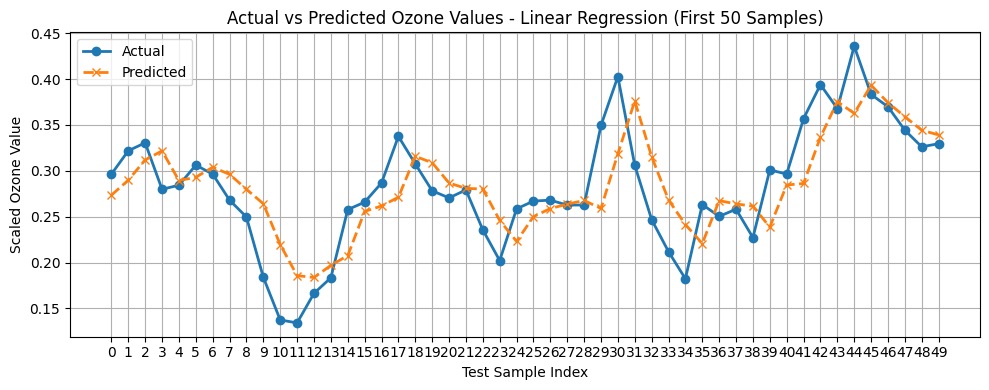

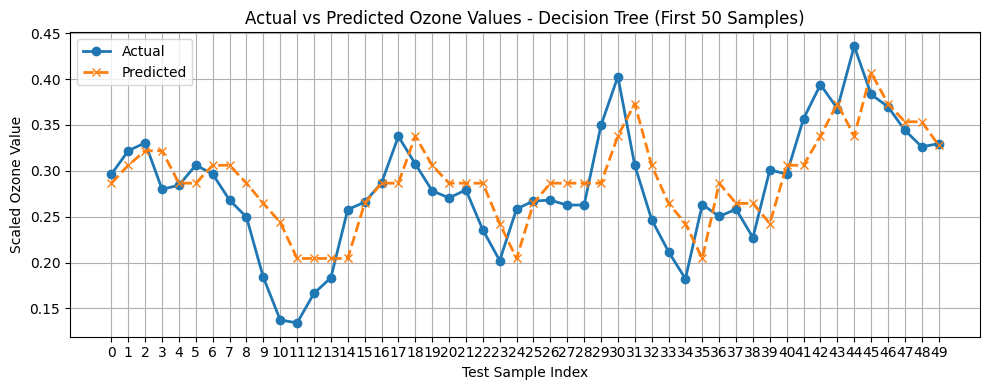

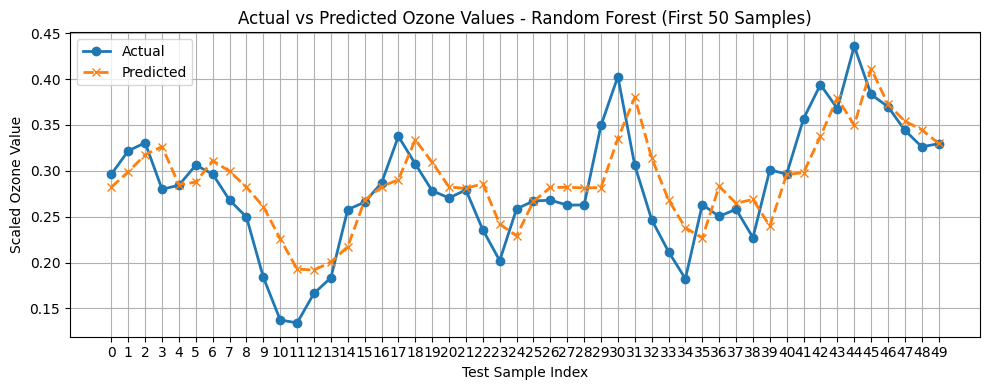

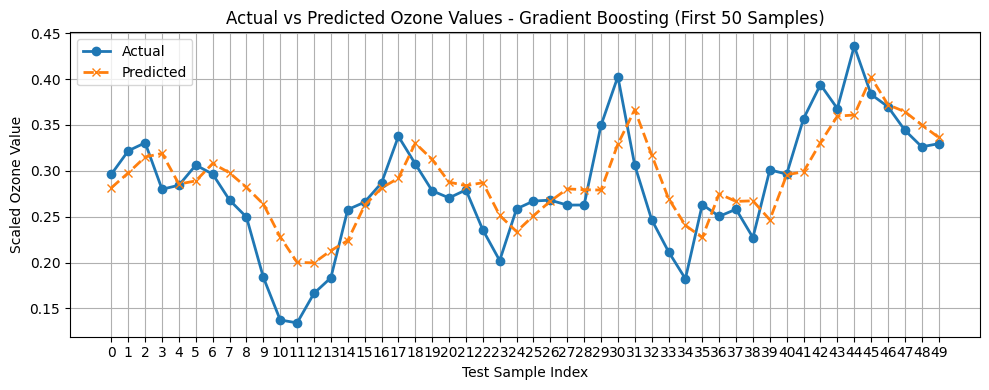

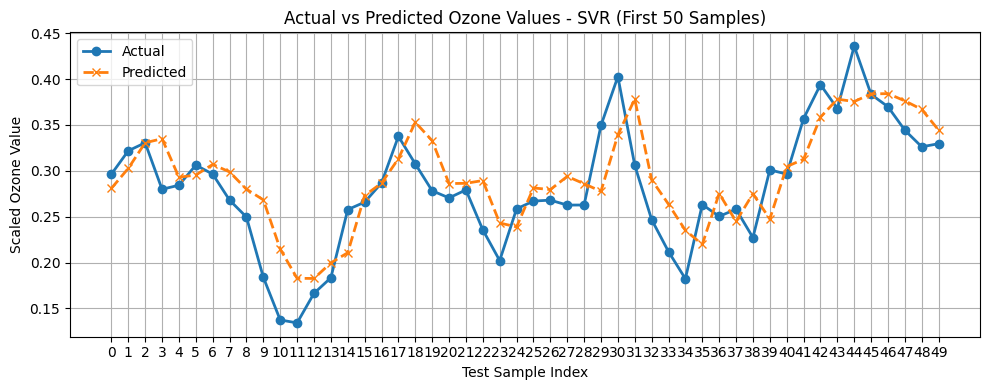

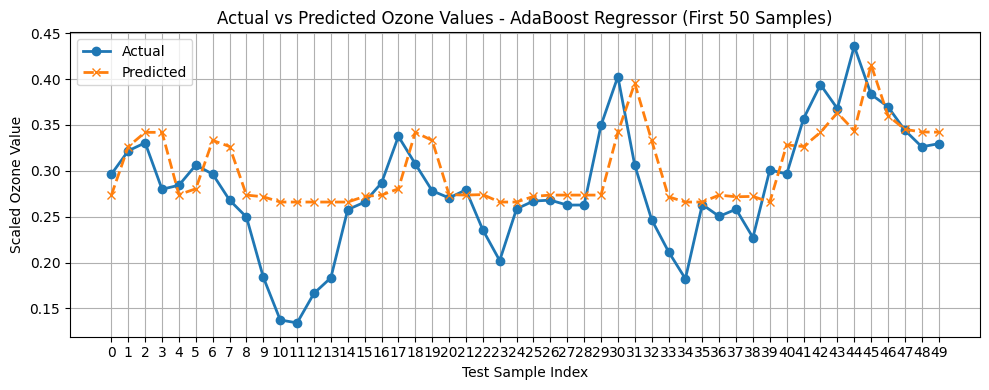

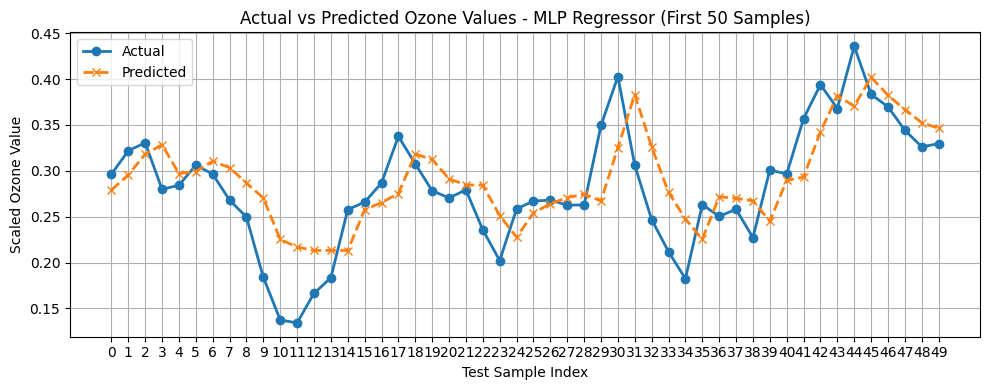

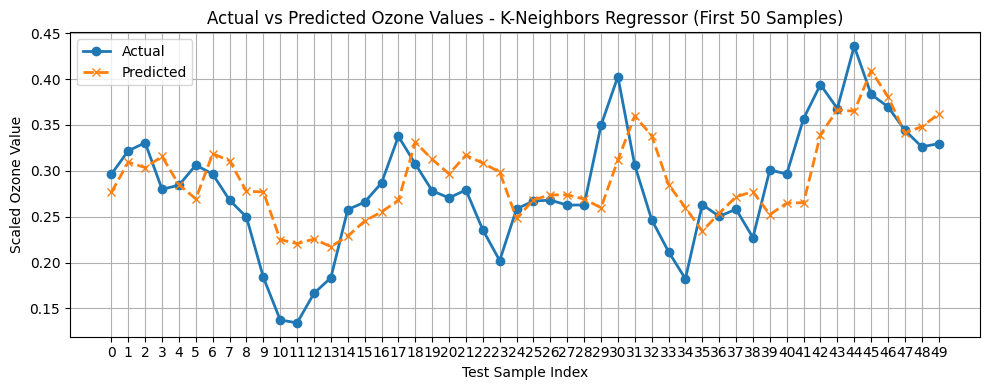

In [234]:
n_display = 50  # Only show the first 10 test samples

for name, res in results.items():
    plt.figure(figsize=(10, 4))
    plt.plot(range(n_display), y_test[:n_display], label='Actual', linewidth=2, marker='o')
    plt.plot(range(n_display), res['Predictions'][:n_display], label='Predicted', linewidth=2, linestyle='--', marker='x')
    
    plt.title(f'Actual vs Predicted Ozone Values - {name} (First {n_display} Samples)')
    plt.xlabel('Test Sample Index')
    plt.ylabel('Scaled Ozone Value')
    plt.xticks(range(n_display))
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


**Performace Comparison**

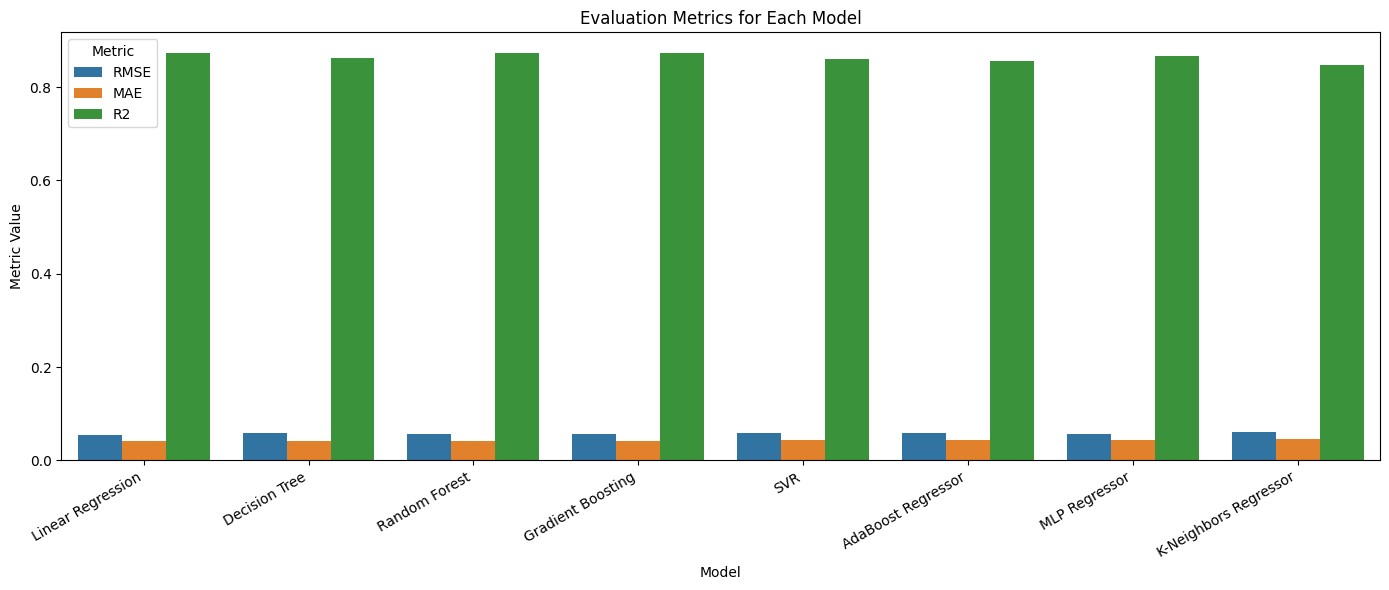

In [235]:
# Prepare data for bar chart
metrics_df = pd.DataFrame({
    'Model': list(results.keys()),
    'RMSE': [res['RMSE'] for res in results.values()],
    'MAE': [res['MAE'] for res in results.values()],
    'R2': [res['R2'] for res in results.values()]
})

plt.figure(figsize=(14, 6))
metrics_df_melted = metrics_df.melt(id_vars='Model', value_vars=['RMSE', 'MAE', 'R2'], var_name='Metric', value_name='Value')
sns.barplot(data=metrics_df_melted, x='Model', y='Value', hue='Metric')
plt.title('Evaluation Metrics for Each Model')
plt.ylabel('Metric Value')
plt.xlabel('Model')
plt.xticks(rotation=30, ha='right')
plt.legend(title='Metric')
plt.tight_layout()
plt.show()